In [94]:
"""
Plots the results from ProSpect SED fitting for stellar and then stellar+AGN Fritz model, along with data calculated from Shay.
"""


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
import csv
from decimal import Decimal
from IPython.display import display, Math
import math
import os
import emcee
import corner

OUTPUT_DIR = "/nvme/scratch/work/alberttg/Summer_project/Data_products"

FILTERS =["F115W", "F150W", "F200W", "F277W", "F356W", "F444W", "F606W", "F814W"]

In [95]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [96]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [97]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params,
                                  x_obs=None, x_err_low=None, x_err_high=None,
                                  gradient=None):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties,
    optionally including x uncertainties projected onto y via the model gradient.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    y_model : array_like
        Model predictions.
    n_params : int
        Number of fitted parameters.
    x_obs : array_like, optional
        Observed x values. Required if x_err_low/x_err_high are given.
    x_err_low : array_like, optional
        Lower (negative) uncertainties on x. If None, treated as zero.
    x_err_high : array_like, optional
        Upper (positive) uncertainties on x. If None, treated as zero.
    gradient : float, optional
        Local gradient of the model (dy/dx), used to project x uncertainty
        onto y. Required if x uncertainties are non-zero.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err_low = np.asarray(y_err_low, dtype=float)
    y_err_high = np.asarray(y_err_high, dtype=float)

    # Use the appropriate uncertainty depending on which side of the data
    sigma_y = np.where(y_model > y_obs, y_err_high, y_err_low)

    # Handle x uncertainties, if provided
    if x_err_low is None:
        x_err_low = np.zeros_like(y_obs)
    else:
        x_err_low = np.asarray(x_err_low, dtype=float)

    if x_err_high is None:
        x_err_high = np.zeros_like(y_obs)
    else:
        x_err_high = np.asarray(x_err_high, dtype=float)

    # If x errors are all zero, skip the x-error projection entirely —
    # this avoids requiring x_obs/gradient when there's nothing to project
    if np.all(x_err_low == 0) and np.all(x_err_high == 0):
        sigma = sigma_y
    else:
        if x_obs is None or gradient is None:
            raise ValueError("x_obs and gradient must be provided when x uncertainties are non-zero.")

        x_obs = np.asarray(x_obs, dtype=float)
        sigma_x = np.where(y_model > y_obs, x_err_high, x_err_low)

        # project x uncertainty onto y using the model gradient, combine in quadrature
        sigma = np.sqrt(sigma_y**2 + (gradient * sigma_x)**2)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [98]:
def calculate_nmad(y, err_high, err_low, y_model):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    sigma = np.where(
        residuals > 0,
        err_low,   # data lie above model
        err_high   # data lie below model
    )

    normalised_residuals = residuals / sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [99]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [100]:
def _parse_err(err, n):
    """
    Normalize an error specification into (err_lo, err_hi) arrays of length n.

    Accepted forms for `err`:
      - None                            -> zeros (no error)
      - scalar or 1D array of length n  -> symmetric error (same as before)
      - [err_high, err_low]             -> asymmetric error; each of
        err_high/err_low can be a scalar (applied to all points) or a
        length-n array (per-point)

    Returned lo/hi are positive distances from the central value
    (lower bound = value - lo, upper bound = value + hi).
    """
    if err is None:
        return np.zeros(n), np.zeros(n)

    # Asymmetric: [err_high, err_low]
    if isinstance(err, (list, tuple)) and len(err) == 2:
        hi = np.asarray(err[0], dtype=float)
        lo = np.asarray(err[1], dtype=float)
        if hi.ndim == 0:
            hi = np.full(n, float(hi))
        if lo.ndim == 0:
            lo = np.full(n, float(lo))
        return lo.copy(), hi.copy()

    # Symmetric: scalar or array, same as before
    arr = np.asarray(err, dtype=float)
    if arr.ndim == 0:
        arr = np.full(n, float(arr))
    return arr.copy(), arr.copy()


def fit_linear_mcmc(x_in, y_in, x_err=None, y_err=None, x_pivot=None,
                     n_walkers=50, n_steps=10000, plot=False, save_path=None):
    """
    Bayesian linear fit y = m*(x - x_pivot) + c with intrinsic scatter,
    supporting asymmetric measurement errors in both x and y.

    x_err / y_err each accept:
      - None, a scalar, or a 1D array of length N (symmetric errors, same
        as before), OR
      - [err_high, err_low] for asymmetric errors, where each of
        err_high/err_low is a scalar (applied to every point) or a
        length-N array (per-point).

    Asymmetric-error handling
    --------------------------
    Each data point's error distribution is modeled as a split-normal
    (two-piece Gaussian): width `sigma_lo` below the measured value and
    `sigma_hi` above it. At every MCMC step, for each point we compare the
    model prediction to the data (delta = model - data) and pick the
    error side consistent with that comparison:
        delta >= 0  ->  use the "hi" error (model sits above the data)
        delta <  0  ->  use the "lo" error (model sits below the data)
    This is applied to both the y errors and the x errors (the latter
    projected into y-space via the slope, m^2 * xerr^2, as in the
    symmetric case). This is the standard practical approximation for
    asymmetric errors in a likelihood — it is exact only when the true
    error distribution really is split-normal, but works well in general
    and reduces to the ordinary symmetric-error likelihood when lo == hi.
    The intrinsic scatter term sigma_int is kept symmetric.
    """
    # --- Step 1: Data Cleaning & Pivot Handling ---
    x = np.asarray(x_in, dtype=float)
    y = np.asarray(y_in, dtype=float)
    n = len(x)

    xe_lo, xe_hi = _parse_err(x_err, n)
    ye_lo, ye_hi = _parse_err(y_err, n)

    xp = 0.0 if x_pivot is None else x_pivot

    mask = (
        np.isfinite(x) & np.isfinite(y)
        & np.isfinite(xe_lo) & np.isfinite(xe_hi)
        & np.isfinite(ye_lo) & np.isfinite(ye_hi)
    )

    # Guard against zero/negative error entries (keeps likelihood well-defined)
    xe_lo = np.where(xe_lo <= 0, 1e-10, xe_lo)
    xe_hi = np.where(xe_hi <= 0, 1e-10, xe_hi)
    ye_lo = np.where(ye_lo <= 0, 1e-10, ye_lo)
    ye_hi = np.where(ye_hi <= 0, 1e-10, ye_hi)

    x, y = x[mask], y[mask]
    xe_lo, xe_hi = xe_lo[mask], xe_hi[mask]
    ye_lo, ye_hi = ye_lo[mask], ye_hi[mask]

    if len(x) < 2:
        raise ValueError("Not enough finite data points.")

    # --- Step 2: Robust Initial Guess ---
    try:
        guess_m, guess_c = np.polyfit(x - xp, y, 1)
    except np.linalg.LinAlgError:
        guess_m, guess_c = 0.0, np.mean(y)

    guess_sigma = np.std(y - (guess_m * (x - xp) + guess_c))

    # --- Step 3: MCMC Functions (3 parameters: m, c, sigma_int) ---
    def log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        m, c, sigma_int = theta
        if sigma_int <= 0:
            return -np.inf

        model = m * (x - xp) + c
        delta = model - y  # positive => model above data

        y_sig = np.where(delta >= 0, yerr_hi, yerr_lo)
        x_sig = np.where(delta >= 0, xerr_hi, xerr_lo)

        sigma2 = y_sig**2 + (m**2 * x_sig**2) + sigma_int**2
        return -0.5 * np.sum(delta**2 / sigma2 + np.log(2 * np.pi * sigma2))

    def log_prior(theta):
        m, c, sigma_int = theta
        if -20.0 < m < 20.0 and -20.0 < c < 20.0 and 0.0 < sigma_int < 10.0:
            return 0.0
        return -np.inf

    def log_probability(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        ll = log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp)
        return lp + ll if np.isfinite(ll) else -np.inf

    # --- Step 4: Run MCMC ---
    ndim = 3
    initial = np.array([guess_m, guess_c, guess_sigma if guess_sigma > 0 else 0.1])
    pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_probability,
        args=(x, y, xe_lo, xe_hi, ye_lo, ye_hi, xp)
    )
    sampler.run_mcmc(pos, n_steps, progress=True)

    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    x_range = np.linspace(x.min(), x.max(), 100)
    m_samples = flat_samples[:, 0]
    c_samples = flat_samples[:, 1]
    sig_samples = flat_samples[:, 2]

    models = m_samples[:, np.newaxis] * (x_range - xp) + c_samples[:, np.newaxis]

    m_med, c_med, sig_med = np.median(flat_samples, axis=0)
    lower_bound = np.percentile(models, 16, axis=0)
    upper_bound = np.percentile(models, 84, axis=0)

    # --- Step 5: Visualization ---
    if plot:
        plt.figure(figsize=(8, 6))
        print(f"Median slope: {m_med:.3f}, Intercept: {c_med:.3f}, Intrinsic Scatter: {sig_med:.3f}")

        # matplotlib expects asymmetric errors as [lower_distances, upper_distances]
        plt.errorbar(
            x, y,
            xerr=[xe_lo, xe_hi], yerr=[ye_lo, ye_hi],
            fmt=".k", alpha=0.4, label="Data", zorder=1
        )
        plt.fill_between(x_range, lower_bound, upper_bound, color="royalblue", alpha=0.3, label=r"1$\sigma$ Confidence")
        plt.plot(x_range, m_med * (x_range - xp) + c_med, color="darkblue", lw=2, label="Median Fit")
        plt.legend()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

        labels = ["Slope $m$", f"Intercept $c$ (at $x={xp}$)", r"$\sigma_{int}$"]
        corner.corner(flat_samples, labels=labels, truths=[m_med, c_med, sig_med], show_titles=True)
        plt.show()

    results = {
        "m_median": m_med,
        "c_median": c_med,
        "sig_int_median": sig_med,
        "m_16": np.percentile(flat_samples[:, 0], 16),
        "m_84": np.percentile(flat_samples[:, 0], 84),
        "c_16": np.percentile(flat_samples[:, 1], 16),
        "c_84": np.percentile(flat_samples[:, 1], 84),
        "sig_int_16": np.percentile(flat_samples[:, 2], 16),
        "sig_int_84": np.percentile(flat_samples[:, 2], 84),
        "x_pivot": xp,
    }

    return results

In [101]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_upper_err : float
        1-sigma upper uncertainty on slope.
    gradient_lower_err : float
        1-sigma lower uncertainty on slope.
    intercept_upper_err : float
        1-sigma upper uncertainty on intercept.
    intercept_lower_err : float
        1-sigma lower uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    line_kwargs = {} if line_kwargs is None else line_kwargs.copy()
    line_kwargs.setdefault("color", colour)
    line_kwargs.setdefault("lw", 2)
    line_kwargs.setdefault("linestyle", "--")

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    xmin, xmax = np.min(x), np.max(x)
    pad = 0.01 * (xmax - xmin)
    x_plot = np.linspace(xmin - pad, xmax + pad, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_upper_err) * x_plot
               + (intercept + intercept_upper_err))

    y_lower = ((gradient - gradient_lower_err) * x_plot
               + (intercept - intercept_lower_err))

    ax.plot(x_plot, y, label=label,zorder=zorder, **line_kwargs)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, zorder=zorder, **band_kwargs)
    

In [102]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    plot_points,
):

    if x_lower_err is None or x_upper_err is None:
        x_lower_err = np.zeros_like(x)
        x_upper_err = np.zeros_like(x)
    
    results = fit_linear_mcmc(x_in=x, y_in=y, 
                              x_err=[x_upper_err, x_lower_err], 
                              y_err=[y_upper_err, y_lower_err], 
                              x_pivot=None, n_walkers=50, n_steps=2000, plot=False, save_path=None)

    gradient = results["m_median"]
    gradient_upper_err = results["m_84"] - results["m_median"]
    gradient_lower_err = results["m_median"] - results["m_16"]
    intercept = results["c_median"]
    intercept_upper_err = results["c_84"] - results["c_median"]
    intercept_lower_err = results["c_median"] - results["c_16"]
    scatter_med = results["sig_int_median"]


    x_dummy_data = np.linspace(0.8 * np.min(x), 1.2 * np.max(x), 500)

    y_model = straight_line(x, gradient, intercept)

    weighted_red_chi = weighted_reduced_chi_squared(y_obs=y, y_err_low=y_upper_err, y_err_high=y_upper_err, y_model=y_model, n_params=2,
                                  x_obs=x, x_err_low=x_lower_err, x_err_high=x_upper_err,
                                  gradient=gradient)

    scatter = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept))

    if ax is not None:
        
        if plot_points==True:

            if isinstance(plot_colours, str):
                plot_colours = [plot_colours] * len(x)

            for xi, yi, xeu, xel, yeu, yel, colour in zip(x, y, x_upper_err, x_lower_err, y_upper_err, y_lower_err, plot_colours):
                ax.errorbar(
                    xi,
                    yi,
                    xerr=[[xel], [xeu]],
                    yerr=[[yel], [yeu]],
                    color=colour,
                    fmt='none',
                    alpha=0.3,
                    lw=0.8,
                    zorder=2
                )

            ax.scatter(
                x,
                y,
                s=20,
                color=plot_colours,
                edgecolor='0.3',
                linewidths=0.5,
                marker='o',
                zorder=3
            )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Scatter from fit = {scatter_med:.3f}")
        print(f"Scatter (NMAD of normalised residuals) = {scatter:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi


In [103]:
def format_value_uncertainty(value, upper_err, lower_err):
    """
    Format a value with asymmetric uncertainties using standard
    significant-figure rules (PDG rounding: 1 sig fig, or 2 if the
    leading digit is 1 or 2).

    Parameters
    ----------
    value : float
        Central value.
    upper_err : float
        +1 sigma uncertainty.
    lower_err : float
        -1 sigma uncertainty.

    Returns
    -------
    value_str, upper_str, lower_str : str
        Formatted value and uncertainties, all rounded to a consistent
        number of decimal places.
    """

    if upper_err == 0 and lower_err == 0:
        return f"{value:.3f}", "0", "0"

    def get_decimals(err):
        if err == 0:
            return 0
        exponent = math.floor(math.log10(abs(err)))
        first_digit = int(abs(err) / 10**exponent)
        sig_figs = 2 if first_digit in [1, 2] else 1
        return -(exponent - (sig_figs - 1))

    # decide precision using whichever error needs more decimal places,
    # so neither error gets rounded away to zero
    decimals = max(get_decimals(upper_err), get_decimals(lower_err))

    value_rounded = round(value, decimals)
    upper_rounded = round(upper_err, decimals)
    lower_rounded = round(lower_err, decimals)

    fmt = f"{{:.{max(decimals, 0)}f}}"

    return fmt.format(value_rounded), fmt.format(upper_rounded), fmt.format(lower_rounded)

In [104]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl


In [105]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [106]:
def filter_best_DIC(stellar_table, stellar_AGN_table):
    """
    Select the stellar mass from either the stellar-only or stellar+AGN fit
    depending on the DIC comparison.

    Uses the AGN model if:
        DIC_AGN < DIC_stellar - 6

    Returns a table containing the best stellar mass estimates and the model
    selected for each galaxy.
    """

    # Match galaxies by ID
    # Some of the headers are the same across both tables, so to avoid confusion, 
    # uniq_col_name keeps the col_name and appends it with stellar or AGN depending on which table it came from.
    table = join(
        stellar_table,
        stellar_AGN_table,
        keys="SURVEY_ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    # Read the relevant columns
    DIC_stellar = np.asarray(table["DIC_stellar"], dtype=float)
    DIC_AGN = np.asarray(table["DIC_AGN"], dtype=float)

    mass_stellar_Q16 = np.asarray(table["StellarMassQ16_stellar"], dtype=float)
    mass_stellar_Q50 = np.asarray(table["StellarMassQ50_stellar"], dtype=float)
    mass_stellar_Q84 = np.asarray(table["StellarMassQ84_stellar"], dtype=float)

    mass_AGN_Q16 = np.asarray(table["StellarMassQ16_AGN"], dtype=float)
    mass_AGN_Q50 = np.asarray(table["StellarMassQ50_AGN"], dtype=float)
    mass_AGN_Q84 = np.asarray(table["StellarMassQ84_AGN"], dtype=float)

    # Decide which model to use
    use_AGN = np.zeros(len(table), dtype=bool)

    mask = ~np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)
    use_AGN[mask] = DIC_AGN[mask] < (DIC_stellar[mask] - 6)

    # If only AGN exists, use it
    use_AGN[np.isnan(DIC_stellar) & ~np.isnan(DIC_AGN)] = True

    # Select best masses
    best_mass_Q16 = np.where(use_AGN, mass_AGN_Q16, mass_stellar_Q16)
    best_mass_Q50 = np.where(use_AGN, mass_AGN_Q50, mass_stellar_Q50)
    best_mass_Q84 = np.where(use_AGN, mass_AGN_Q84, mass_stellar_Q84)
    best_model = np.where(use_AGN, "stellar_AGN", "stellar")

    table["Best_StellarMassQ16"] = best_mass_Q16
    table["Best_StellarMassQ50"] = best_mass_Q50
    table["Best_StellarMassQ84"] = best_mass_Q84
    table["Best_Model"] = best_model

    print("DIC filtered table names: ",table.colnames)
    
    return table

In [107]:
def plot_stellar_masses(combined_table):
    """
    Plotting Q50 stellar mass from stars only against Q50 mass from stars and AGN.
    """
    # Stellar mass data:
    stellar_only_q16 = combined_table["StellarMassQ16_stellar"].data
    stellar_only_q50 = combined_table["StellarMassQ50_stellar"].data
    stellar_only_q84 = combined_table["StellarMassQ84_stellar"].data
    
    stellar_AGN_q16 = combined_table["StellarMassQ16_AGN"].data
    stellar_AGN_q50 = combined_table["StellarMassQ50_AGN"].data
    stellar_AGN_q84 = combined_table["StellarMassQ84_AGN"].data


    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(stellar_only_q50) - np.log10(stellar_only_q16),
        np.log10(stellar_only_q84) - np.log10(stellar_only_q50)
    ]
    xerr = [
        np.log10(stellar_AGN_q50) - np.log10(stellar_AGN_q16),
        np.log10(stellar_AGN_q84) - np.log10(stellar_AGN_q50)
    ]
    
    fig, ax = plt.subplots(figsize=(10,10))

    (ax, stellar_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=np.log10(stellar_AGN_q50),
        x_upper_err=xerr[1],
        x_lower_err=xerr[0],
        y=np.log10(stellar_only_q50),
        y_upper_err=yerr[1],
        y_lower_err=yerr[0],
        plot_colours='C0',
        ax=ax,
        plot_points=True,
    )
    
    plot_best_fit_with_uncertainty(ax, stellar_dummy_data, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label='Line of best fit',
                              colour='red',
                              fill=False,
                              zorder=1,
                              )
    
    # 1:1 line
    mmin = min(np.min(np.log10(stellar_AGN_q50)),np.min(np.log10(stellar_only_q50)))
    mmax = max(np.max(np.log10(stellar_AGN_q50)),np.max(np.log10(stellar_only_q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars only)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars + AGN)',fontdict={'fontsize': 15})
    ax.set_ylim(0.95 * mmin, 1.05 * mmax)
    ax.set_xlim(0.95 * mmin, 1.05 * mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [108]:
def check_Q50_mass_against_best(mass_Q16, mass_Q50, mass_Q84, mass_best):
    """
    Plotting stellar mass Q50 and errors (y-axis) against stellar mass best (x-axis).
    Will be done for stellar only data and stellar+AGN data when called separately.
    """
    
    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(mass_Q50) - np.log10(mass_Q16),
        np.log10(mass_Q84) - np.log10(mass_Q50)]

    t, p = ttest_rel(mass_best, mass_Q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(mass_best),
        np.log10(mass_Q50),
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(mass_best)),np.min(np.log10(mass_Q50)))
    mmax = max(np.max(np.log10(mass_best)),np.max(np.log10(mass_Q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Best)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return

In [109]:
def bhm_vs_sm_plot(table):
    """
    Plots log10(bh mass/ solar mass) against log10(stellar mass/ solar mass) 
    with line of best fit and best fit from Reines and Volonteri.

    Second half of function calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    """
    #Reines and Volonteri data:
    # Refer to Eq 5 of their paper
    RV_gradient = 1.05
    RV_gradient_uncertainty =0.11
    RV_intercept = 7.45 - RV_gradient*11
    RV_intercept_uncertainty = np.sqrt(0.08**2 + (11*0.11)**2)
    #------------------------------------------------------------------------------------------------------------------------------------------
    # Load data
    survey = table["SURVEY"].data
    jades = np.asarray(["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"], dtype=str)
    primer =  np.asarray(["PRIMER-COSMOS","PRIMER-UDS"], dtype=str)
    ceers = np.asarray(["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"], dtype=str)

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data
    
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(np.abs(bh_mass - bh_mass_lower_err))
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass
    #------------------------------------------------------------------------------------------------------------------------------------------

    log_stellar_mass = np.log10(stellar_mass_Q50)
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - log_stellar_mass
    log_stellar_mass_lower_err = log_stellar_mass - np.log10(stellar_mass_Q16)

    colours = np.empty(len(survey), dtype=object)
    for i, s in enumerate(survey):
        if s in jades:
            colours[i] = 'tab:blue'
        if s in ceers:
            colours[i] = 'tab:purple'
        if s in primer:
            colours[i] = 'tab:orange'

    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='JADES',
                markerfacecolor='tab:blue',
                markeredgecolor='0.3',
                linewidth=0.5,
                markersize=7),
                
            Line2D([0], [0], marker='o', color='w',
                label='CEERS',
                markerfacecolor='tab:purple',
                markeredgecolor='0.3',
                linewidth=0.5,
                markersize=7),
                    
            Line2D([0], [0], marker='o', color='w',
                label='PRIMER',
                markerfacecolor='tab:orange',
                markeredgecolor='0.3',
                linewidth=0.5,
                markersize=7)    ]

    fig, ax = plt.subplots(figsize=(10, 10))

    ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi = \
    fit_straight_line_and_plot(x=log_stellar_mass, x_upper_err=log_stellar_mass_upper_err, x_lower_err=log_stellar_mass_lower_err, 
                            y=log_bh_mass, y_upper_err=log_bh_mass_upper_err, y_lower_err=log_bh_mass_lower_err, 
                            plot_colours=colours, ax=ax, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax, x_dummy_data, gradient, intercept,
        gradient_upper_err, gradient_lower_err,
        intercept_upper_err, intercept_lower_err,
        "Line of best fit", "red", fill=True, zorder=3,
    )

    line_legend = ax.legend(loc='upper right')
    ax.add_artist(line_legend)

    plot_best_fit_with_uncertainty(
        ax, x_dummy_data, RV_gradient, RV_intercept,
        RV_gradient_uncertainty, RV_gradient_uncertainty,
        RV_intercept_uncertainty, RV_intercept_uncertainty,
        "Reines & Volonteri", "black", fill=True, zorder=1,
    )

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    plt.xlim(5,12)
    
    line_legend = ax.legend(loc='upper left')
    ax.legend(handles=legend_elements, title="Survey", loc='upper right')
    ax.add_artist(line_legend)
    plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})$"
    ))
    

    RV_grad, RV_grad_upper_err, RV_grad_lower_err = format_value_uncertainty(RV_gradient, RV_gradient_uncertainty, RV_gradient_uncertainty)
    RV_inter, RV_inter_upper_err, RV_inter_lower_err = format_value_uncertainty(RV_intercept, RV_intercept_uncertainty, RV_intercept_uncertainty)
    print("")
    print("Reines & Volonteri equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({RV_grad} \pm {RV_grad_upper_err})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({RV_inter} \pm {RV_inter_upper_err})$"
    ))


In [110]:
def bhm_vs_sm_plot_same_axis(stellar_table, stellar_AGN_table, filtered_table):
    """
    Plots log10(bh mass/ solar mass) against log10(stellar mass/ solar mass) 
    with line of best fit and best fit from Reines and Volonteri.

    Second half of function calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    """
    #Reines and Volonteri data:
    # Refer to Eq 5 of their paper
    RV_gradient = 1.05
    RV_gradient_uncertainty =0.11
    RV_intercept = 7.45 - RV_gradient*11
    RV_intercept_uncertainty = np.sqrt(0.08**2 + (11*0.11)**2)
    #------------------------------------------------------------------------------------------------------------------------------------------

    jades = np.asarray(["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"], dtype=str)
    primer =  np.asarray(["PRIMER-COSMOS","PRIMER-UDS"], dtype=str)
    ceers = np.asarray(["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"], dtype=str)

    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='JADES',
                markerfacecolor='tab:blue',
                markeredgecolor='0.3',
                linewidth=0.5,
                markersize=7),
                
            Line2D([0], [0], marker='o', color='w',
                label='CEERS',
                markerfacecolor='tab:purple',
                markeredgecolor='0.3',
                linewidth=0.5,
                markersize=7),
                    
            Line2D([0], [0], marker='o', color='w',
                label='PRIMER',
                markerfacecolor='tab:orange',
                markeredgecolor='0.3',
                linewidth=0.5,
                markersize=7)    ]
    
    def colours(survey):
        colours = np.empty(len(survey), dtype=object)
        for i, s in enumerate(survey):
            if s in jades:
                colours[i] = 'tab:blue'
            if s in ceers:
                colours[i] = 'tab:purple'
            if s in primer:
                colours[i] = 'tab:orange'
        return colours

    #------------------------------------------------------------------------------------------------------------------------------------------
    # Stellar+AGN
    survey_AGN = stellar_AGN_table["SURVEY"].data

    colours_AGN = colours(survey_AGN)

    stellar_mass_Q16_AGN = stellar_AGN_table["StellarMassQ16"].data
    stellar_mass_Q50_AGN = stellar_AGN_table["StellarMassQ50"].data
    stellar_mass_Q84_AGN = stellar_AGN_table["StellarMassQ84"].data
    
    bh_mass_AGN = stellar_AGN_table["BH_MASS"].data
    bh_mass_lower_err_AGN = stellar_AGN_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_AGN = stellar_AGN_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_AGN = np.log10(bh_mass_AGN)
    log_bh_mass_lower_err_AGN = log_bh_mass_AGN - np.log10(np.abs(bh_mass_AGN - bh_mass_lower_err_AGN))
    log_bh_mass_upper_err_AGN = np.log10(bh_mass_AGN + bh_mass_upper_err_AGN) - log_bh_mass_AGN
    
    log_stellar_mass_AGN = np.log10(stellar_mass_Q50_AGN)
    log_stellar_mass_upper_err_AGN = np.log10(stellar_mass_Q84_AGN) - log_stellar_mass_AGN
    log_stellar_mass_lower_err_AGN = log_stellar_mass_AGN - np.log10(stellar_mass_Q16_AGN)
    #------------------------------------------------------------------------------------------------------------------------------------------
    # stellar only
    survey_stellar = stellar_table["SURVEY"].data

    colours_stellar = colours(survey_stellar)

    stellar_mass_Q16_stellar = stellar_table["StellarMassQ16"].data
    stellar_mass_Q50_stellar = stellar_table["StellarMassQ50"].data
    stellar_mass_Q84_stellar = stellar_table["StellarMassQ84"].data
    
    bh_mass_stellar = stellar_table["BH_MASS"].data
    bh_mass_lower_err_stellar = stellar_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_stellar = stellar_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_stellar = np.log10(bh_mass_stellar)
    log_bh_mass_lower_err_stellar = log_bh_mass_stellar - np.log10(np.abs(bh_mass_stellar - bh_mass_lower_err_stellar))
    log_bh_mass_upper_err_stellar = np.log10(bh_mass_stellar + bh_mass_upper_err_stellar) - log_bh_mass_stellar
    
    log_stellar_mass_stellar = np.log10(stellar_mass_Q50_stellar)
    log_stellar_mass_upper_err_stellar = np.log10(stellar_mass_Q84_stellar) - log_stellar_mass_stellar
    log_stellar_mass_lower_err_stellar = log_stellar_mass_stellar - np.log10(stellar_mass_Q16_stellar)
    #------------------------------------------------------------------------------------------------------------------------------------------
    # final filtered table
    survey_filtered = filtered_table["SURVEY"].data

    colours_filtered= colours(survey_filtered)

    stellar_mass_Q16_filtered = filtered_table["StellarMassQ16"].data
    stellar_mass_Q50_filtered = filtered_table["StellarMassQ50"].data
    stellar_mass_Q84_filtered = filtered_table["StellarMassQ84"].data

    bh_mass_filtered = filtered_table["BH_MASS"].data
    bh_mass_lower_err_filtered = filtered_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_filtered = filtered_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_filtered = np.log10(bh_mass_filtered)
    log_bh_mass_lower_err_filtered = log_bh_mass_filtered - np.log10(np.abs(bh_mass_filtered - bh_mass_lower_err_filtered))
    log_bh_mass_upper_err_filtered = np.log10(bh_mass_filtered + bh_mass_upper_err_filtered) - log_bh_mass_filtered

    log_stellar_mass_filtered = np.log10(stellar_mass_Q50_filtered)
    log_stellar_mass_upper_err_filtered = np.log10(stellar_mass_Q84_filtered) - log_stellar_mass_filtered
    log_stellar_mass_lower_err_filtered = log_stellar_mass_filtered - np.log10(stellar_mass_Q16_filtered)
    #------------------------------------------------------------------------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10,10))

    # Calculate the line of best fit for stellar only data:
    (_, stellar_x_dummy_data, stellar_gradient, stellar_gradient_upper_err, stellar_gradient_lower_err, stellar_intercept, stellar_intercept_upper_err, stellar_intercept_lower_err, stellar_weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=log_stellar_mass_stellar,
        x_upper_err=log_stellar_mass_upper_err_stellar,
        x_lower_err=log_stellar_mass_lower_err_stellar,
        y=log_bh_mass_stellar,
        y_upper_err=log_bh_mass_upper_err_stellar,
        y_lower_err=log_bh_mass_lower_err_stellar,
        plot_colours=colours_stellar,
        ax=None,
        plot_points=False,
    )
    
    
    # Calculate the best fit for stellar+AGN data:
    (_, AGN_x_dummy_data, AGN_gradient, AGN_gradient_upper_err, AGN_gradient_lower_err, AGN_intercept, AGN_intercept_upper_err, AGN_intercept_lower_err, AGN_weighted_red_chi
     ) = fit_straight_line_and_plot(
            x=log_stellar_mass_AGN,
            x_upper_err=log_stellar_mass_upper_err_AGN,
            x_lower_err=log_stellar_mass_lower_err_AGN,
            y=log_bh_mass_AGN,
            y_upper_err=log_bh_mass_upper_err_AGN,
            y_lower_err=log_bh_mass_lower_err_AGN,
            plot_colours=colours_AGN,
            ax=ax,
            plot_points=False,
        )

    # Calculate the best fit for final filtered SED data:
    (ax, filtered_x_dummy_data, filtered_gradient, filtered_gradient_upper_err, filtered_gradient_lower_err, filtered_intercept, filtered_intercept_upper_err, filtered_intercept_lower_err, filtered_weighted_red_chi
         ) = fit_straight_line_and_plot(
                x=log_stellar_mass_filtered,
                x_upper_err=log_stellar_mass_upper_err_filtered,
                x_lower_err=log_stellar_mass_lower_err_filtered,
                y=log_bh_mass_filtered,
                y_upper_err=log_bh_mass_upper_err_filtered,
                y_lower_err=log_bh_mass_lower_err_filtered,
                plot_colours=colours_filtered,
                ax=ax,
                plot_points=True,
            )
    
    # Make a plot of AGN best fit line
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        AGN_gradient,
        AGN_intercept,
        AGN_gradient_upper_err,
        AGN_gradient_lower_err,
        AGN_intercept_upper_err,
        AGN_intercept_lower_err,
        "Stellar+AGN fit",
        "red",
        fill=False,
        zorder=1,
    )
    
    # Plot equation of stellar best fit but using AGN stellar masses
    
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        stellar_gradient,
        stellar_intercept,
        stellar_gradient_upper_err,
        stellar_gradient_lower_err,
        stellar_intercept_upper_err,
        stellar_intercept_lower_err,
        "Stellar fit",
        "blue",
        fill=False,
        zorder=1
    )


    # Plot equation of filtered best fit
    plot_best_fit_with_uncertainty(
            ax,
            filtered_x_dummy_data,
            filtered_gradient,
            filtered_intercept,
            filtered_gradient_upper_err,
            filtered_gradient_lower_err,
            filtered_intercept_upper_err,
            filtered_intercept_lower_err,
            "Filtered fit",
            "magenta",
            fill=True,
            zorder=1,
        )
    
    # Plot RV line of best fit on AGN stellar masses
    plot_best_fit_with_uncertainty(
        ax,
        filtered_x_dummy_data,
        RV_gradient,
        RV_intercept,
        RV_gradient_uncertainty,
        RV_gradient_uncertainty,
        RV_intercept_uncertainty,
        RV_intercept_uncertainty,
        "Reines & Volonteri",
        "black",
        fill=True,
        zorder=1,
    )

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    plt.xlim(5,12)
    
    line_legend = ax.legend(loc='upper right')
    ax.legend(handles=legend_elements, title="Survey", loc='upper left')
    ax.add_artist(line_legend)
    plt.show()

    
    print("")
    print("Reines & Volonteri equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({RV_gradient} \pm {RV_gradient_uncertainty})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({RV_intercept} \pm {RV_intercept_uncertainty})$"
    ))

    grad_AGN, grad_upper_err_AGN, grad_lower_err_AGN = format_value_uncertainty(
        AGN_gradient, AGN_gradient_upper_err, AGN_gradient_lower_err
    )
    inter_AGN, inter_upper_err_AGN, inter_lower_err_AGN = format_value_uncertainty(
        AGN_intercept, AGN_intercept_upper_err, AGN_intercept_lower_err
    )

    print("Line of best fit equation for AGN fit: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad_AGN}^{{+{grad_upper_err_AGN}}}_{{-{grad_lower_err_AGN}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter_AGN}^{{+{inter_upper_err_AGN}}}_{{-{inter_lower_err_AGN}}})$"
    ))


    grad_stellar, grad_upper_err_stellar, grad_lower_err_stellar = format_value_uncertainty(
        stellar_gradient, stellar_gradient_upper_err, stellar_gradient_lower_err
    )
    inter_stellar, inter_upper_err_stellar, inter_lower_err_stellar = format_value_uncertainty(
        stellar_intercept, stellar_intercept_upper_err, stellar_intercept_lower_err
    )

    print("Line of best fit equation for stellar only fit: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad_stellar}^{{+{grad_upper_err_stellar}}}_{{-{grad_lower_err_stellar}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter_stellar}^{{+{inter_upper_err_stellar}}}_{{-{inter_lower_err_stellar}}})$"
    ))


In [111]:
def bhsmr_eq(samples):
    """
    Calculates black hole stellar mass ratio given bh_mass (not logged) and stellar mass, in solar masses.
    """
    bh_mass = samples[:,0]
    stellar_mass = samples[:,1]

    return np.log10(bh_mass / stellar_mass)

In [112]:
def bhsmr_plots(table):
    """
    Calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    Also plots bhsmr against SFR10 and SFR100.

    Returns table appended with new columns containing bhsmr, bhsmr_upper_err, bhsmr_lower_err.
    """
    #----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # bhsmr vs stellar mass
    # Load data
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data

    # Calculating bhsmr and errs
    bh_mass_Q16 = np.abs(bh_mass - bh_mass_lower_err) # galaxy 3919 has lower_err bigger than bh_mass
    bh_mass_Q50 = bh_mass
    bh_mass_Q84 = bh_mass + bh_mass_upper_err

    bhsmr = np.empty(len(bh_mass_Q50))
    bhsmr_upper_err = np.empty(len(bh_mass_Q50))
    bhsmr_lower_err = np.empty(len(bh_mass_Q50))

    for i in range(len(bh_mass)):
        bhsmr[i], bhsmr_upper_err[i], bhsmr_lower_err[i] = uncertainty_propagation([[bh_mass_Q16[i], bh_mass_Q50[i], bh_mass_Q84[i]], 
                                                                                    [stellar_mass_Q16[i], stellar_mass_Q50[i], stellar_mass_Q84[i]]], bhsmr_eq)     
    
    # Analysis and plotting
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)
    log_stellar_mass_lower_err = np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16)
    log_stellar_mass = np.log10(stellar_mass_Q50)

    fig, ax = plt.subplots(figsize=(10, 10))

    ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi = \
    fit_straight_line_and_plot(x=log_stellar_mass, x_upper_err=log_stellar_mass_upper_err, x_lower_err=log_stellar_mass_lower_err, 
                               y=bhsmr, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
                               plot_colours='C0', ax=ax, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax, x_dummy_data, gradient, intercept,
        gradient_upper_err, gradient_lower_err,
        intercept_upper_err, intercept_lower_err,
        "Line of best fit", "red", fill=True, zorder=3,
    )

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_xlim(5,12)
    ax.set_ylim(0.98 * np.min(bhsmr), 1.02 * np.max(bhsmr))
    #ax.set_aspect('equal')
    ax.legend()
    plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})$"
    ))

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # bhsmr vs SFR10
    # Load data
    sfr10_Q16 = table["SFR10Q16"]
    sfr10_Q50 = table["SFR10Q50"]
    sfr10_Q84 = table["SFR10Q84"]
    # (units of solar masses / yr)

    log_sfr10_lower_err = np.log10(sfr10_Q50) - np.log10(sfr10_Q16)
    log_sfr10_upper_err = np.log10(sfr10_Q84) - np.log10(sfr10_Q50)
    log_sfr10 = np.log10(sfr10_Q50)

    # Analysis and plotting
    # Everything with 10 is relating to SFR10

    mask10 = sfr10_Q50 >= 1

    fig10, ax10 = plt.subplots(figsize=(10, 10))

    ax10, x_dummy_data10, gradient10, gradient_upper_err10, gradient_lower_err10, intercept10, intercept_upper_err10, intercept_lower_err10, weighted_red_chi10 = \
    fit_straight_line_and_plot(x=log_sfr10[mask10], x_upper_err=log_sfr10_upper_err[mask10], x_lower_err=log_sfr10_lower_err[mask10], 
                                y=bhsmr[mask10], y_upper_err=bhsmr_upper_err[mask10], y_lower_err=bhsmr_lower_err[mask10],
                                plot_colours='C0', ax=ax10, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax10, x_dummy_data10, gradient10, intercept10,
        gradient_upper_err10, gradient_lower_err10,
        intercept_upper_err10, intercept_lower_err10,
        "Line of best fit", "red", fill=True, zorder=3,
    )

    ax10.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax10.set_xlabel(r'$\log_{10}(SFR10 M_\odot yr^{{-1}})$',fontdict={'fontsize': 15})
    ax10.set_xlim(-0.25, x_dummy_data10[-1] * 1.05)
    #ax10.set_ylim(np.min(bhsmr) * 0.9, np.max(bhsmr) * 1.1)
    ax10.legend()
    plt.show()

    grad10, grad_upper_err10, grad_lower_err10 = format_value_uncertainty(gradient10, gradient_upper_err10, gradient_lower_err10)
    inter10, inter_upper_err10, inter_lower_err10 = format_value_uncertainty(intercept10, intercept_upper_err10, intercept_lower_err10)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad10}^{{+{grad_upper_err10}}}_{{-{grad_lower_err10}}})\,"
        rf"\log_{{10}}(SFR10 / M_\odot yr^{{-1}})"
        rf" + ({inter10}^{{+{inter_upper_err10}}}_{{-{inter_lower_err10}}})$"
    ))
    
    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # bhsmr vs SFR100
    # Load data
    sfr100_Q16 = table["SFR10Q16"]
    sfr100_Q50 = table["SFR100Q50"]
    sfr100_Q84 = table["SFR100Q84"]
    # (units of solar masses / yr)

    log_sfr100_lower_err = np.abs(np.log10(sfr100_Q50) - np.log10(sfr100_Q16))
    log_sfr100_upper_err = np.abs(np.log10(sfr100_Q84) - np.log10(sfr100_Q50))
    log_sfr100 = np.log10(sfr100_Q50)

    # Analysis and plotting
    # Everything with 100 is relating to SFR100

    mask100 = sfr100_Q50 >= 1

    fig100, ax100 = plt.subplots(figsize=(10, 10))

    ax100, x_dummy_data100, gradient100, gradient_upper_err100, gradient_lower_err100, intercept100, intercept_upper_err100, intercept_lower_err100, weighted_red_chi100 = \
    fit_straight_line_and_plot(x=log_sfr100[mask100], x_upper_err=log_sfr100_upper_err[mask100], x_lower_err=log_sfr100_lower_err[mask100], 
                                y=bhsmr[mask100], y_upper_err=bhsmr_upper_err[mask100], y_lower_err=bhsmr_lower_err[mask100],
                                plot_colours='C0', ax=ax100, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax100, x_dummy_data100, gradient100, intercept100,
        gradient_upper_err100, gradient_lower_err100,
        intercept_upper_err100, intercept_lower_err100,
        "Line of best fit", "red", fill=True, zorder=3,
    )

    ax100.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole to Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax100.set_xlabel(r'$\log_{10}(SFR100 M_\odot yr^{{-1}})$',fontdict={'fontsize': 15})
    ax100.set_xlim(-0.25, x_dummy_data100[-1] * 1.02)
    #ax100.set_ylim(np.min(bhsmr) * 0.9, np.max(bhsmr) * 1.1)
    ax100.legend()
    plt.show()

    grad100, grad_upper_err100, grad_lower_err100 = format_value_uncertainty(gradient100, gradient_upper_err100, gradient_lower_err100)
    inter100, inter_upper_err100, inter_lower_err100 = format_value_uncertainty(intercept100, intercept_upper_err100, intercept_lower_err100)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad100}^{{+{grad_upper_err100}}}_{{-{grad_lower_err100}}})\,"
        rf"\log_{{10}}(SFR100 / M_\odot yr^{{-1}})"
        rf" + ({inter100}^{{+{inter_upper_err100}}}_{{-{inter_lower_err100}}})$"
    ))

    #-----------------------------------------------------------------------------------------------------------------------
    table["bhsmr"] = bhsmr
    table["bhsmr_upper_err"] = bhsmr_upper_err
    table["bhsmr_lower_err"] = bhsmr_lower_err

    return table


In [113]:
def AGNfrac_vs_bhsmr(table):
    """
    Plots AGN fraction from Fritz06 models against bhsmr ratio.
    """
    # Load data
    AGNfrac_Q16 = np.asarray(table["AGN_Dale_fracQ16"].data)
    AGNfrac_Q50 = np.asarray(table["AGN_Dale_fracQ50"].data)
    AGNfrac_Q84 = np.asarray(table["AGN_Dale_fracQ84"].data)

    AGNfrac_lower_err = AGNfrac_Q50 - AGNfrac_Q16
    AGNfrac_upper_err = AGNfrac_Q84 - AGNfrac_Q50

    bhsmr = np.asarray(table["bhsmr"].data)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 10))

    ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi = \
    fit_straight_line_and_plot(x=bhsmr, x_upper_err=bhsmr_upper_err, x_lower_err=bhsmr_lower_err,
                               y=AGNfrac_Q50, y_upper_err=AGNfrac_upper_err, y_lower_err=AGNfrac_lower_err,
                               plot_colours='C0', ax=ax, plot_points=True)

    # Note: fit line is not drawn here (matches previous plot_linear=False
    # behaviour) - the relationship is not well described by a straight
    # line on this log y-scale, but the fit statistics are still reported below.

    ax.set_yscale('log')
    ax.set_ylabel(r'$AGN fraction$ (Fraction of flux from AGN over total)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax.set_xlim(-6,3)
    ax.legend()
    plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})$"
    ))


In [114]:
def plot_AGNlum(stellar_table, stellar_AGN_table, galaxy_table):

    """
    Plotting Q50 AGN luminosity against Q50 stellar mass, showing by colour which SED model was selected (stellar only or stellar+AGN).

    Plotting difference between stellar mass from stellar only table and stellar AGN table.

    Plotting AGN luminosity from model against Shay's data.
    """
    DIC_filtered_table = filter_best_DIC(stellar_table, stellar_AGN_table)
    # Makes a combined table of data from both fits and appends new columns with mass_best etc. and the model selected for each galaxy (stellar only or stellar+AGN)

    DIC_filtered_table = join(
        DIC_filtered_table,
        galaxy_table,
        keys="SURVEY_ID"
    )

    #Load data
    stellar_mass_Q16 = DIC_filtered_table["Best_StellarMassQ16"].data
    stellar_mass_Q50 = DIC_filtered_table["Best_StellarMassQ50"].data
    stellar_mass_Q84 = DIC_filtered_table["Best_StellarMassQ84"].data
    model = DIC_filtered_table["Best_Model"].data
    AGNlum_Q16 = DIC_filtered_table["AGNlumQ16"].data
    AGNlum_Q50 = DIC_filtered_table["AGNlumQ50"].data
    AGNlum_Q84 = DIC_filtered_table["AGNlumQ84"].data

    log_stellar_mass_errs = [
        np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16),
        np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)]
    
    log_AGNlum_errs = [
        np.log10(AGNlum_Q50) - np.log10(AGNlum_Q16),
        np.log10(AGNlum_Q84) - np.log10(AGNlum_Q50)]
    
    log_AGNlum = np.log10(AGNlum_Q50)
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Making colour plot of model AGNlum against stellar mass
    
    xerr = log_stellar_mass_errs
    yerr = log_AGNlum_errs

    AGN = model == "stellar_AGN"
    stellar = model == "stellar"

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        xerr=[xerr[0][AGN], xerr[1][AGN]],
        yerr=[yerr[0][AGN], yerr[1][AGN]],
        fmt='None',
        color='red',
        lw=0.8,
        alpha=0.2,
        )

    ax.scatter(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        s=20,
        color='red',
        alpha=0.8,
        label='Stellar + AGN'
        )

    ax.errorbar(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        xerr=[xerr[0][stellar], xerr[1][stellar]],
        yerr=[yerr[0][stellar], yerr[1][stellar]],
        fmt='None',
        color='blue',
        lw=0.8,
        alpha=0.2,
        label='Stellar only'
    )

    ax.scatter(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        s=20,
        color='blue',
        alpha=0.8,
        label='Stellar only'
    )
    ax.legend()

    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylabel(r'$\log_{10}(L_{\rm AGN}/L_\odot)$ (Model AGN Luminosity Q50)',fontdict={'fontsize': 15})
    ax.set_xlim(0.95 * np.min(np.log10(stellar_mass_Q50)), 1.05 * np.max(np.log10(stellar_mass_Q50)))
    ax.legend(["Stellar + AGN", "Stellar only"])
    plt.show()
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting difference between stellar mass across both models against model AGNlum to see if fit was necessary
    # Residual = stellar - stellar+AGN because I expect stellar only fit to over estimate M_star

    log_mass_resid = np.log10(DIC_filtered_table["StellarMassQ50_stellar"].data) - np.log10(DIC_filtered_table["StellarMassQ50_AGN"].data)
    #log_mass_resid = np.log10(mass_resid)
    
    log_StellarMassQ50_stellar_errs = [
        np.log10(DIC_filtered_table["StellarMassQ50_stellar"].data) - np.log10(DIC_filtered_table["StellarMassQ16_stellar"].data),
        np.log10(DIC_filtered_table["StellarMassQ84_stellar"].data) - np.log10(DIC_filtered_table["StellarMassQ50_stellar"].data)]
    
    log_StellarMassQ50_AGN_errs = [
        np.log10(DIC_filtered_table["StellarMassQ50_AGN"].data) - np.log10(DIC_filtered_table["StellarMassQ16_AGN"].data),
        np.log10(DIC_filtered_table["StellarMassQ84_AGN"].data) - np.log10(DIC_filtered_table["StellarMassQ50_AGN"].data)]
    
    log_mass_resid_lower_err = np.sqrt( (log_StellarMassQ50_stellar_errs[0])**2
                                   + (log_StellarMassQ50_AGN_errs[0])**2)
    
    log_mass_resid_upper_err = np.sqrt( (log_StellarMassQ50_stellar_errs[1])**2
                                   + (log_StellarMassQ50_AGN_errs[1])**2) 
    #--------------------------------------------
    fwhm = DIC_filtered_table["FWHM"]
    
    colours = np.empty(len(fwhm), dtype=object)
    colours[fwhm < 100] = 'tab:red'
    colours[(fwhm >= 100) & (fwhm < 1000)] = 'tab:orange'
    colours[(fwhm >= 1000)] = 'tab:green'
    
    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='FWHM < 100',
                markerfacecolor='tab:red',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='100 ≤ FWHM < 1000',
                markerfacecolor='tab:orange',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='FWHM ≥ 1000',
                markerfacecolor='tab:green',      
                markeredgecolor='k',
                markersize=7)
        ]
    #--------------------------------------------
    fig, (ax, ax_zoom) = plt.subplots(1, 2, figsize=(20, 10), sharex=True)
    
    for axis in (ax, ax_zoom):
        axis.errorbar(
            x=log_AGNlum,
            y=log_mass_resid,
            xerr=log_AGNlum_errs,
            yerr=[log_mass_resid_lower_err, log_mass_resid_upper_err],
            fmt='none',
            alpha=0.15,
            lw=0.8,
            zorder=2
        )
        # I've plotted the errorbars separate to the plot to make them more transparent than the points
        axis.scatter(
            log_AGNlum,
            log_mass_resid,
            c=colours,
            s=25,
            edgecolors='k',
            linewidths=0.3,
            zorder=3
        )

        axis.axhline(0,color='0.4',lw=0.8,alpha=0.6)

        axis.set_xlabel(r'$\log_{10}(L_{AGN})$ (Fritz06 model AGN Luminosity)',fontdict={'fontsize': 14})

        # line_legend = ax.legend(loc='upper right')
        ax.legend(handles=legend_elements, title='FWHM', loc='upper left')
        # ax.add_artist(line_legend)

    ax.set_ylabel(r'$\Delta log_{10}(M_\star/M_\odot)$ (Stellar Mass log10 difference between stellar only and stellar+AGN model Q50)',fontdict={'fontsize': 14})

    # Limits
    xmin = 0.99 * log_AGNlum.min()
    xmax = 1.01 * log_AGNlum.max()

    ax.set_xlim(xmin, xmax)

    ax_zoom.set_ylim(-1, 2.8)

    plt.tight_layout()
    plt.show()

    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting model AGNlum against lum from data   
    # Variables ending in 2 refer to this 2nd plot

    #Load data
    L_bol = DIC_filtered_table["L_BH_BOL"].data
    L_upper_err = DIC_filtered_table["L_BH_BOL_UPPER_ERR"].data
    L_lower_err = DIC_filtered_table["L_BH_BOL_LOWER_ERR"].data

    log_L_bol = np.log10(L_bol)
    log_L_upper_err = np.log10(L_bol + L_upper_err) - log_L_bol
    log_L_lower_err = log_L_bol - np.log10(L_bol - L_lower_err)

    fig2, ax2 = plt.subplots(figsize=(10, 10))

    ax2, x_dummy_data2, gradient2, gradient_upper_err2, gradient_lower_err2, intercept2, intercept_upper_err2, intercept_lower_err2, weighted_red_chi2 = \
    fit_straight_line_and_plot(x=log_L_bol, x_upper_err=log_L_upper_err, x_lower_err=log_L_lower_err, 
                               y=log_AGNlum, y_upper_err=log_AGNlum_errs[1], y_lower_err=log_AGNlum_errs[0],
                               plot_colours='C0', ax=ax2, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax2, x_dummy_data2, gradient2, intercept2,
        gradient_upper_err2, gradient_lower_err2,
        intercept_upper_err2, intercept_lower_err2,
        "Line of best fit", "red", fill=False, zorder=3,
    )

    # 1:1 line
    mmin = min(np.min(log_L_bol),np.min(log_AGNlum))
    mmax = max(np.max(log_L_bol),np.max(log_AGNlum))

    ax2.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax2.set_ylabel(r'$\log_{10}(L_{AGN})$ (Fritz06 model AGN Luminosity)',fontdict={'fontsize': 15})
    ax2.set_xlabel(r'$\log_{10}(L_{H\alpha,bol})$ (Observed AGN luminosity)',fontdict={'fontsize': 15})
    plt.xlim(0.95 * x_dummy_data2[0],1.05 * x_dummy_data2[-1])
    #ax.set_aspect('equal')
    ax2.legend()
    plt.show()

    grad2, grad_upper_err2, grad_lower_err2 = format_value_uncertainty(gradient2, gradient_upper_err2, gradient_lower_err2)
    inter2, inter_upper_err2, inter_lower_err2 = format_value_uncertainty(intercept2, intercept_upper_err2, intercept_lower_err2)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
        rf" = ({grad2}^{{+{grad_upper_err2}}}_{{-{grad_lower_err2}}})\,"
        rf"\log_{{10}}(SFR100 / M_\odot yr^{{-1}})"
        rf" + ({inter2}^{{+{inter_upper_err2}}}_{{-{inter_lower_err2}}})$"
    ))


In [115]:
def sSFR_eq(samples):

    sfr = samples[:,0]
    stellar_mass = samples[:,1]

    sSFR = sfr / stellar_mass
    return sSFR

In [116]:
def sSFR_vs_M(ProSpect_table):
    """
    SFR / stellar mass against stellar mass, for SFR10 and SFR100.
    Only plots and fits where log10(sSFR) > -13.
    """

    # Load data
    stellar_mass_Q16 = ProSpect_table["StellarMassQ16"].data
    stellar_mass_Q50 = ProSpect_table["StellarMassQ50"].data
    stellar_mass_Q84 = ProSpect_table["StellarMassQ84"].data

    log_stellar_mass = np.log10(stellar_mass_Q50)
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - log_stellar_mass
    log_stellar_mass_lower_err = log_stellar_mass - np.log10(stellar_mass_Q16)

    sfr10_Q50 = ProSpect_table["SFR10Q50"].data
    sfr10_Q16 = ProSpect_table["SFR10Q16"].data
    sfr10_Q84 = ProSpect_table["SFR10Q84"].data

    sfr100_Q50 = ProSpect_table["SFR100Q50"].data
    sfr100_Q16 = ProSpect_table["SFR100Q16"].data
    sfr100_Q84 = ProSpect_table["SFR100Q84"].data    

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # sSFR10 vs stellar mass plot
    # Calculating SFR10

    sSFR10 = np.empty(len(sfr10_Q50))
    sSFR10_upper_err = np.empty(len(sfr10_Q50))
    sSFR10_lower_err = np.empty(len(sfr10_Q50))

    for i in range(len(sfr10_Q50)):
        sSFR10[i], sSFR10_upper_err[i], sSFR10_lower_err[i] = uncertainty_propagation([[sfr10_Q16[i], sfr10_Q50[i], sfr10_Q84[i]], 
                                                                                    [stellar_mass_Q16[i], stellar_mass_Q50[i], stellar_mass_Q84[i]]], sSFR_eq)    

    log_sSFR10 = np.log10(sSFR10)
    log_sSFR10_upper_err = np.log10(sSFR10_upper_err + sSFR10) - log_sSFR10
    log_sSFR10_lower_err = log_sSFR10 - np.log10(sSFR10 - sSFR10_lower_err) 

    # Analysis and plotting

    mask10 = log_sSFR10 > -13
    
    fig10, ax10 = plt.subplots(figsize=(10, 10))

    ax10, x_dummy10, gradient10, gradient_upper_err10, gradient_lower_err10, intercept10, intercept_upper_err10, intercept_lower_err10, weighted_red_chi10 = \
    fit_straight_line_and_plot(x=log_stellar_mass[mask10], x_upper_err=log_stellar_mass_upper_err[mask10], x_lower_err=log_stellar_mass_lower_err[mask10], 
                                y=log_sSFR10[mask10], y_upper_err=log_sSFR10_upper_err[mask10], y_lower_err=log_sSFR10_lower_err[mask10],
                                plot_colours='C0', ax=ax10, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax10, x_dummy10, gradient10, intercept10,
        gradient_upper_err10, gradient_lower_err10,
        intercept_upper_err10, intercept_lower_err10,
        "Line of best fit", "red", fill=True, zorder=3,
    )

    ax10.set_ylabel(r'$\log_{10}(sSFR10 / yr^{-1})$',fontdict={'fontsize': 15})
    ax10.set_xlabel(r'$\log_{10}(M_\star / M\odot$)',fontdict={'fontsize': 15})
    plt.xlim(5,12)
    plt.ylim(-13, -6)
    ax10.legend()
    plt.show()

    grad10, grad_upper_err10, grad_lower_err10 = format_value_uncertainty(gradient10, gradient_upper_err10, gradient_lower_err10)
    inter10, inter_upper_err10, inter_lower_err10 = format_value_uncertainty(intercept10, intercept_upper_err10, intercept_lower_err10)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(sSFR10/yr^{{-1}})"
        rf" = ({grad10}^{{+{grad_upper_err10}}}_{{-{grad_lower_err10}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter10}^{{+{inter_upper_err10}}}_{{-{inter_lower_err10}}})$"
    ))
    

    #-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # sSFR100 vs stellar mass plot
    # Calculating SFR10
    sSFR100 = np.empty(len(sfr100_Q50))
    sSFR100_upper_err = np.empty(len(sfr100_Q50))
    sSFR100_lower_err = np.empty(len(sfr100_Q50))

    for i in range(len(sfr100_Q50)):
        sSFR100[i], sSFR100_upper_err[i], sSFR100_lower_err[i] = uncertainty_propagation([[sfr100_Q16[i], sfr100_Q50[i], sfr100_Q84[i]], 
                                                                                    [stellar_mass_Q16[i], stellar_mass_Q50[i], stellar_mass_Q84[i]]], sSFR_eq)    

    log_sSFR100 = np.log10(sSFR100)
    log_sSFR100_upper_err = np.log10(sSFR100 + sSFR100_upper_err) - log_sSFR100
    log_sSFR100_lower_err = log_sSFR100 - np.log10(sSFR100 - sSFR100_lower_err) 

    # Analysis and plotting

    mask100 = log_sSFR100 > -13

    fig100, ax100 = plt.subplots(figsize=(10, 10))

    ax100, x_dummy100, gradient100, gradient_upper_err100, gradient_lower_err100, intercept100, intercept_upper_err100, intercept_lower_err100, weighted_red_chi100 = \
    fit_straight_line_and_plot(x=log_stellar_mass[mask100], x_upper_err=log_stellar_mass_upper_err[mask100], x_lower_err=log_stellar_mass_lower_err[mask100], 
                                y=log_sSFR100[mask100], y_upper_err=log_sSFR100_upper_err[mask100], y_lower_err=log_sSFR100_lower_err[mask100],
                                plot_colours='C0', ax=ax100, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax100, x_dummy100, gradient100, intercept100,
        gradient_upper_err100, gradient_lower_err100,
        intercept_upper_err100, intercept_lower_err100,
        "Line of best fit", "red", fill=True, zorder=3,
    )

    ax100.set_ylabel(r'$\log_{10}(sSFR100 / yr^{-1})$',fontdict={'fontsize': 15})
    ax100.set_xlabel(r'$\log_{10}(M_\star / M\odot$)',fontdict={'fontsize': 15})
    plt.xlim(5,12)      
    plt.ylim(-13, -6)
    ax100.legend()
    plt.show()


    grad100, grad_upper_err100, grad_lower_err100 = format_value_uncertainty(gradient100, gradient_upper_err100, gradient_lower_err100)
    inter100, inter_upper_err100, inter_lower_err100 = format_value_uncertainty(intercept100, intercept_upper_err100, intercept_lower_err100)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(sSFR100/yr^{{-1}})"
        rf" = ({grad100}^{{+{grad_upper_err100}}}_{{-{grad_lower_err100}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter100}^{{+{inter_upper_err100}}}_{{-{inter_lower_err100}}})$"
    ))
   

    ProSpect_table["sSFR10"] = sSFR10
    ProSpect_table["sSFR10_upper_err"] = sSFR10_upper_err
    ProSpect_table["sSFR10_lower_err"] = sSFR10_lower_err
    ProSpect_table["sSFR100"] = sSFR100
    ProSpect_table["sSFR100_upper_err"] = sSFR100_upper_err
    ProSpect_table["sSFR100_lower_err"] =  sSFR100_lower_err

    return ProSpect_table


In [117]:
def edd_ratio_vs_bh_m(table):
    """
    Plots Eddington ratio against black hole mass.
    """
    #Load data
    edd_ratio = np.asarray(table["EDD_RATIO"], dtype="float")
    edd_ratio_upper_err = np.asarray(table["EDD_RATIO_UPPER_ERR"], dtype="float")
    edd_ratio_lower_err = np.asarray(table["EDD_RATIO_LOWER_ERR"], dtype="float")

    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(bh_mass - bh_mass_lower_err)
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass

    fwhm = np.asarray(table["FWHM"], dtype="float")
    #------------------------------------------------------------------------------------------------------------------------
    # Colours for plotting
    colours = np.empty(len(fwhm), dtype=object)
    colours[fwhm < 100] = 'tab:red'
    colours[(fwhm >= 100) & (fwhm < 1000)] = 'tab:orange'
    colours[(fwhm >= 1000)] = 'tab:green'

    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='FWHM < 100',
                markerfacecolor='tab:red',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='100 ≤ FWHM < 1000',
                markerfacecolor='tab:orange',
                markeredgecolor='k',
                markersize=7),

            Line2D([0], [0], marker='o', color='w',
                label='FWHM ≥ 1000',
                markerfacecolor='tab:green',      
                markeredgecolor='k',
                markersize=7)
        ]
    #------------------------------------------------------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 10))

    ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi = \
    fit_straight_line_and_plot(x=log_bh_mass, x_upper_err=log_bh_mass_upper_err, x_lower_err=log_bh_mass_lower_err, 
                               y=edd_ratio, y_upper_err=edd_ratio_upper_err, y_lower_err=edd_ratio_lower_err,
                               plot_colours=colours, ax=ax, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax, x_dummy_data, gradient, intercept,
        gradient_upper_err, gradient_lower_err,
        intercept_upper_err, intercept_lower_err,
        "Line of best fit", "red", fill=True, zorder=3,
    )
    
    ax.set_ylabel(r'$L_{AGN}/L_{Edd}$ (Eddington ratio)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.axhline(0,color='0.4',lw=0.8,alpha=0.6)
    plt.ylim(-1, 30)
    ax.legend(handles=legend_elements, title='FWHM')
    plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    print("Line of best fit equation: ")
    display(Math(
        rf"$L_{{AGN}}/L_{{Edd}}"
        rf" = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})\,"
        rf"\log_{{10}}(M_{{BH}}/M_\odot)"
        rf" + ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})$"
    ))


In [118]:
def SFR_vs_M(table):
    """
    Plots log10(SFR) against log10(stellar mass) and calculates line of best fit.
    I only plot plots where SFR > 1.
    """
    # Load data
    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data

    log_stellar_mass = np.log10(stellar_mass_Q50)
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - log_stellar_mass
    log_stellar_mass_lower_err = log_stellar_mass - np.log10(stellar_mass_Q16)

    sfr10_Q50 = table["SFR10Q50"].data
    sfr10_Q16 = table["SFR10Q16"].data
    sfr10_Q84 = table["SFR10Q84"].data

    sfr100_Q50 = table["SFR100Q50"].data
    sfr100_Q16 = table["SFR100Q16"].data
    sfr100_Q84 = table["SFR100Q84"].data   
    #--------------------------------------------------------------------------
    # Plotting logSFR10 against log stellar mass

    mask = sfr10_Q50 > 1

    log_SFR10 = np.log10(sfr10_Q50)
    log_SFR10_upper_err = np.log10(sfr10_Q84) - log_SFR10
    log_SFR10_lower_err = log_SFR10 - np.log10(sfr10_Q16)

    fig10, ax10 = plt.subplots(figsize=(10, 10))

    ax10, x_dummy_data10, gradient10, gradient_upper_err10, gradient_lower_err10, intercept10, intercept_upper_err10, intercept_lower_err10, weighted_red_chi10 = \
        fit_straight_line_and_plot(x=log_stellar_mass[mask], x_upper_err=log_stellar_mass_upper_err[mask], x_lower_err=log_stellar_mass_lower_err[mask], 
                                y=log_SFR10[mask], y_upper_err=log_SFR10_upper_err[mask], y_lower_err=log_SFR10_lower_err[mask],
                                plot_colours='C0', ax=ax10, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax10, x_dummy_data10, gradient10, intercept10,
        gradient_upper_err10, gradient_lower_err10,
        intercept_upper_err10, intercept_lower_err10,
        "Line of best fit", "red", fill=False, zorder=3,
    )

    ax10.set_ylabel(r'$\log_{10}(SFR10 / yr^{-1})$',fontdict={'fontsize': 15})
    ax10.set_xlabel(r'$\log_{10}(M_\star / M\odot$)',fontdict={'fontsize': 15})
    ax10.set_xlim(0.98 * np.min(log_stellar_mass[mask]), 1.02 * np.max(log_stellar_mass[mask]))
    ax10.set_ylim(-0.5, np.max(log_SFR10) * 1.02)
    ax10.legend()
    plt.show()


    grad10, grad_upper_err10, grad_lower_err10 = format_value_uncertainty(gradient10, gradient_upper_err10, gradient_lower_err10)
    inter10, inter_upper_err10, inter_lower_err10 = format_value_uncertainty(intercept10, intercept_upper_err10, intercept_lower_err10)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(SFR100/yr^{{-1}})"
        rf" = ({grad10}^{{+{grad_upper_err10}}}_{{-{grad_lower_err10}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter10}^{{+{inter_upper_err10}}}_{{-{inter_lower_err10}}})$"
    ))
    
    #---------------------------------------------------------------------------------------------------------------------------
    # Plotting logSFR100 against log stellar mass

    mask100 = sfr100_Q50 > 1

    log_SFR100 = np.log10(sfr100_Q50)
    log_SFR100_upper_err = np.log10(sfr100_Q84) - log_SFR100
    log_SFR100_lower_err = log_SFR100 - np.log10(sfr100_Q16)

    fig100, ax100 = plt.subplots(figsize=(10, 10))

    ax100, x_dummy_data100, gradient100, gradient_upper_err100, gradient_lower_err100, intercept100, intercept_upper_err100, intercept_lower_err100, weighted_red_chi100 = \
        fit_straight_line_and_plot(x=log_stellar_mass[mask100], x_upper_err=log_stellar_mass_upper_err[mask100], x_lower_err=log_stellar_mass_lower_err[mask100], 
                                y=log_SFR100[mask100], y_upper_err=log_SFR100_upper_err[mask100], y_lower_err=log_SFR100_lower_err[mask100],
                                plot_colours='C0', ax=ax100, plot_points=True)

    plot_best_fit_with_uncertainty(
        ax100, x_dummy_data100, gradient100, intercept100,
        gradient_upper_err100, gradient_lower_err100,
        intercept_upper_err100, intercept_lower_err100,
        "Line of best fit", "red", fill=False, zorder=3,
    )
    
    ax100.set_ylabel(r'$\log_{10}(SFR100 / yr^{-1})$',fontdict={'fontsize': 15})
    ax100.set_xlabel(r'$\log_{10}(M_\star / M\odot$)',fontdict={'fontsize': 15})
    ax100.set_xlim(0.98 * np.min(log_stellar_mass[mask100]), 1.02 * np.max(log_stellar_mass[mask100]))
    ax100.set_ylim(-0.5, np.max(log_SFR10) * 1.02)
    ax100.legend()
    plt.show()



    grad100, grad_upper_err100, grad_lower_err100 = format_value_uncertainty(gradient100, gradient_upper_err100, gradient_lower_err100)
    inter100, inter_upper_err100, inter_lower_err100 = format_value_uncertainty(intercept100, intercept_upper_err100, intercept_lower_err100)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(SFR100/yr^{{-1}})"
        rf" = ({grad100}^{{+{grad_upper_err100}}}_{{-{grad_lower_err100}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter100}^{{+{inter_upper_err100}}}_{{-{inter_lower_err100}}})$"
    ))


In [119]:
def plot_galaxy_colours(table):

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data

    log_stellar_mass = np.log10(stellar_mass_Q50)
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - log_stellar_mass
    log_stellar_mass_lower_err = log_stellar_mass - np.log10(stellar_mass_Q16)

    redshift = np.asarray(table['REDSHIFT'].data, dtype=float)
    
    mag_150 = table["mag_AB_F150W"].data
    mag_150_err = table["mag_AB_err_F150W"].data
    mag_606 = table["mag_AB_F606W"].data
    mag_606_err = table["mag_AB_err_F606W"].data

    mask = (np.isfinite(mag_150) & np.isfinite(mag_150_err) & np.isfinite(mag_606) & np.isfinite(mag_606_err))

    galaxy_colour = mag_606[mask] - mag_150[mask]

    g_c_err = np.sqrt( (mag_150_err[mask])**2 + (mag_606_err[mask])**2 )


    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        x=log_stellar_mass[mask],
        y=galaxy_colour,
        xerr=[log_stellar_mass_lower_err[mask], log_stellar_mass_upper_err[mask]],
        yerr=g_c_err,
        fmt='None',
        color='C0',
        lw=0.8,
        alpha=0.2,
        zorder=1
        )

    scatter = ax.scatter(
        log_stellar_mass[mask],
        galaxy_colour,
        s=20,
        c=redshift[mask],
        cmap='plasma',
        alpha=0.9,
        zorder=2
        )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Redshift (z)', fontsize=13)
    
    ax.legend(loc='upper right')
    ax.set_xlim(np.min(log_stellar_mass)*0.95, np.max(log_stellar_mass)*1.05)
    ax.set_ylim(np.min(galaxy_colour)*0.92, np.max(galaxy_colour)*1.1)
    ax.set_ylabel(r'$m_{F606W} - m_{F150W}$ (Colour)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar mass)',fontdict={'fontsize': 15})
    plt.show()

    return table

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    913   142R x 452C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, 

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:04<00:00, 456.53it/s]



For plot below: 
Reduced chi squared = 4.55
Scatter from fit = 0.186
Scatter (NMAD of normalised residuals) = 3.790


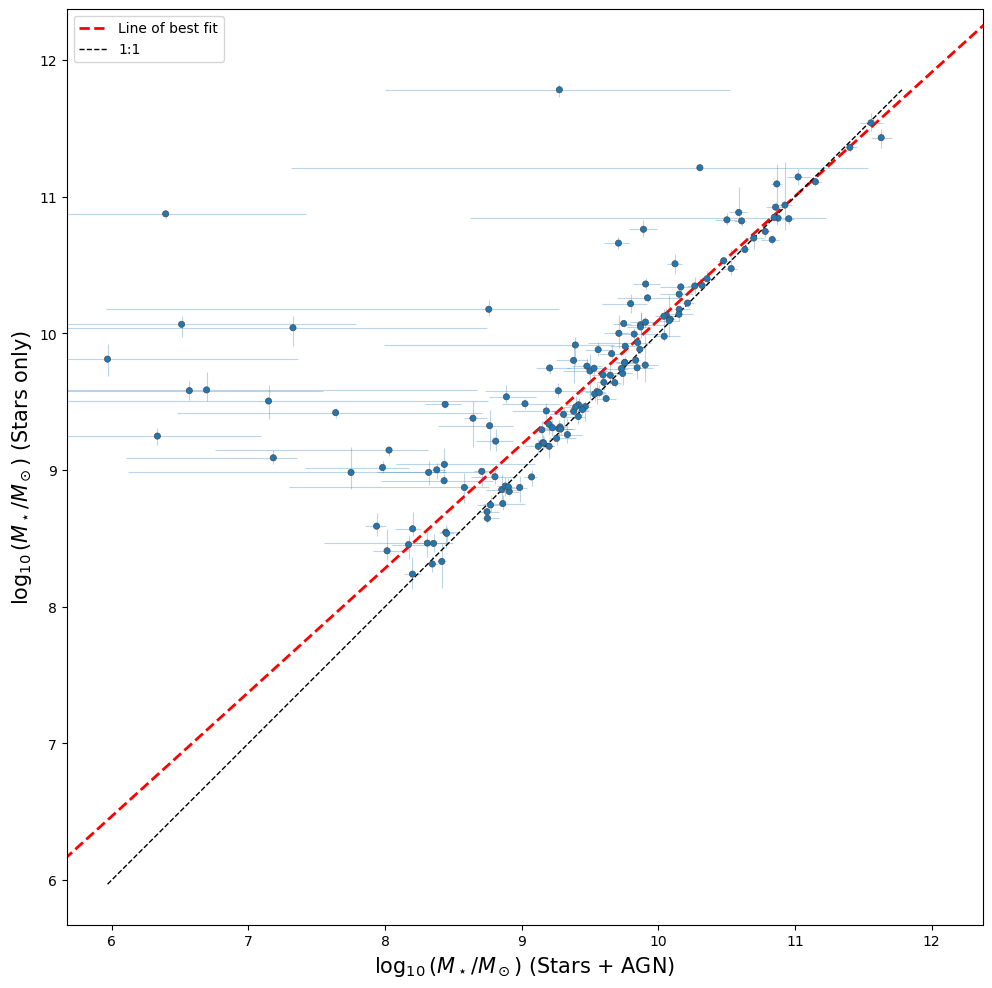

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    951   142R x 471C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 

100%|██████████| 2000/2000 [00:03<00:00, 503.34it/s]



For plot below: 
Reduced chi squared = 637
Scatter from fit = 0.825
Scatter (NMAD of normalised residuals) = 8.878


100%|██████████| 2000/2000 [00:04<00:00, 431.09it/s]



For plot below: 
Reduced chi squared = 400
Scatter from fit = 0.818
Scatter (NMAD of normalised residuals) = 7.839


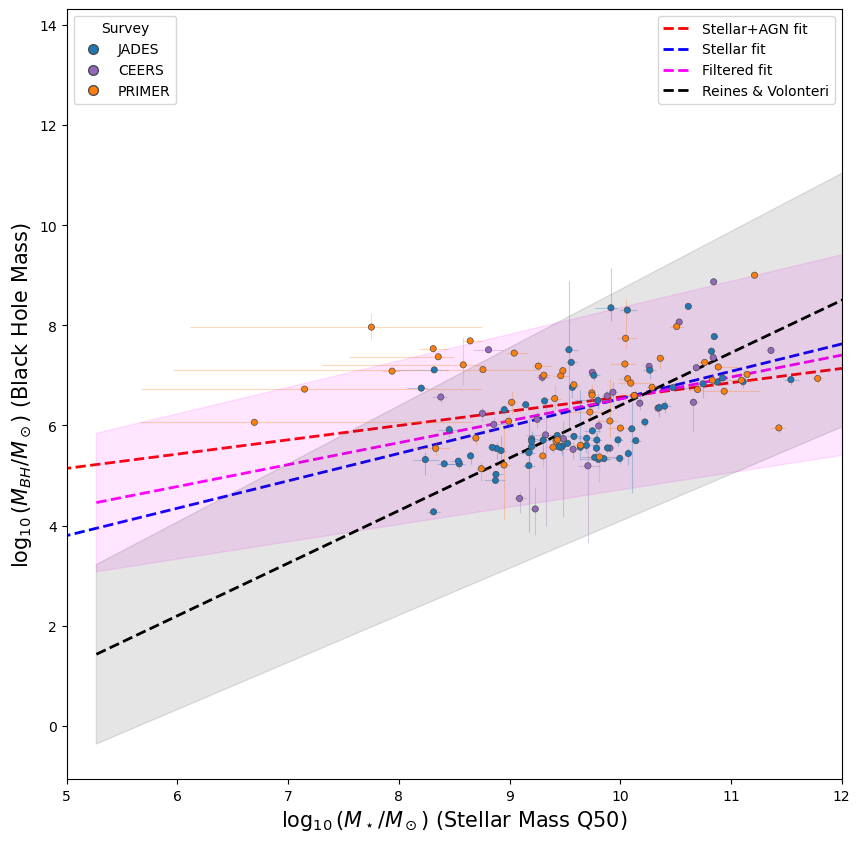


Reines & Volonteri equation: 


<IPython.core.display.Math object>

Line of best fit equation for AGN fit: 


<IPython.core.display.Math object>

Line of best fit equation for stellar only fit: 


<IPython.core.display.Math object>


Plot of black hole mass against stellar mass from SED fit of stellar light only


100%|██████████| 2000/2000 [00:04<00:00, 438.01it/s]



For plot below: 
Reduced chi squared = 278
Scatter from fit = 0.793
Scatter (NMAD of normalised residuals) = 7.564


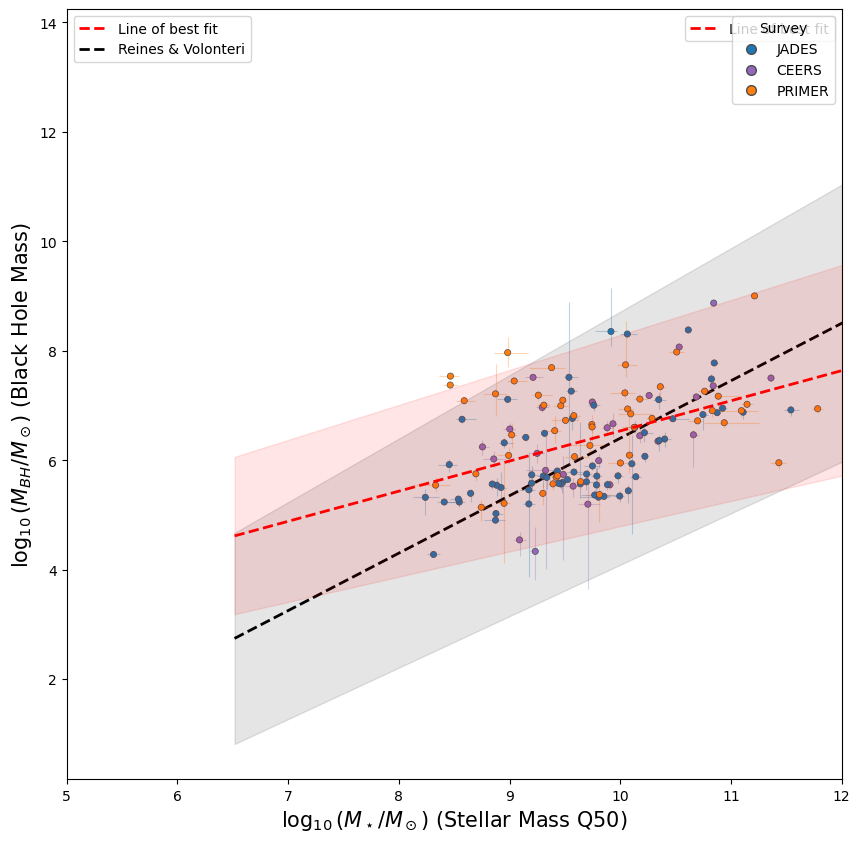

Line of best fit equation: 


<IPython.core.display.Math object>


Reines & Volonteri equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:06<00:00, 291.30it/s]



For plot below: 
Reduced chi squared = 165
Scatter from fit = 0.790
Scatter (NMAD of normalised residuals) = 6.792


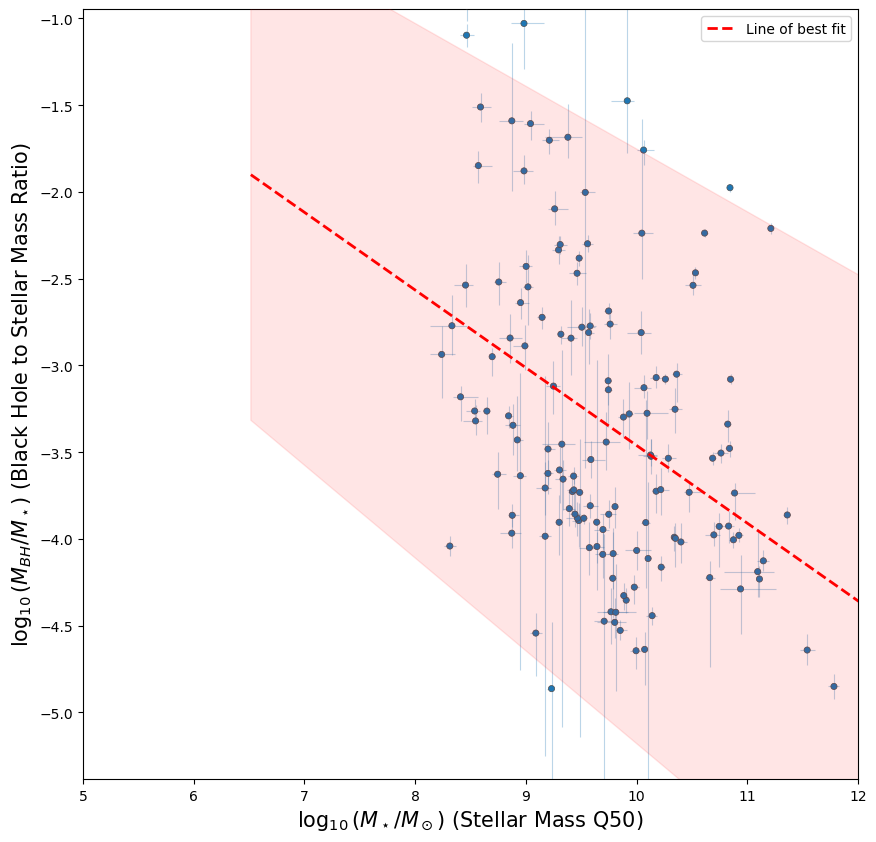

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 452.10it/s]



For plot below: 
Reduced chi squared = 65.6
Scatter from fit = 0.713
Scatter (NMAD of normalised residuals) = 6.451


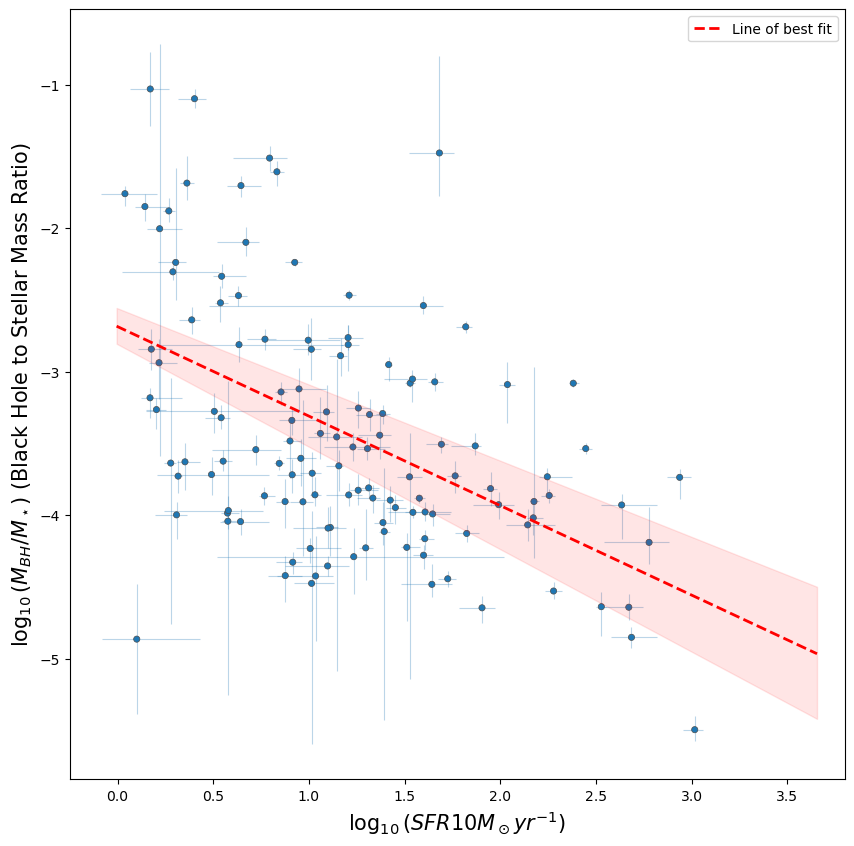

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 451.36it/s]



For plot below: 
Reduced chi squared = 68.5
Scatter from fit = 0.709
Scatter (NMAD of normalised residuals) = 6.179


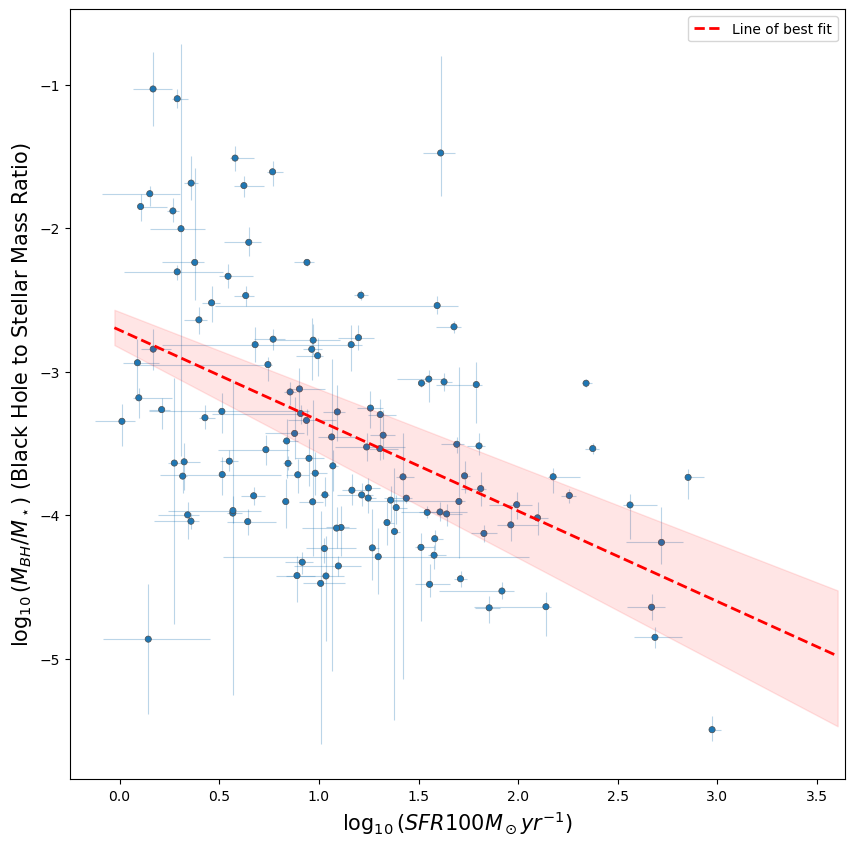

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 411.37it/s]



For plot below: 
Reduced chi squared = 83.9
Scatter from fit = 0.481
Scatter (NMAD of normalised residuals) = 5.972


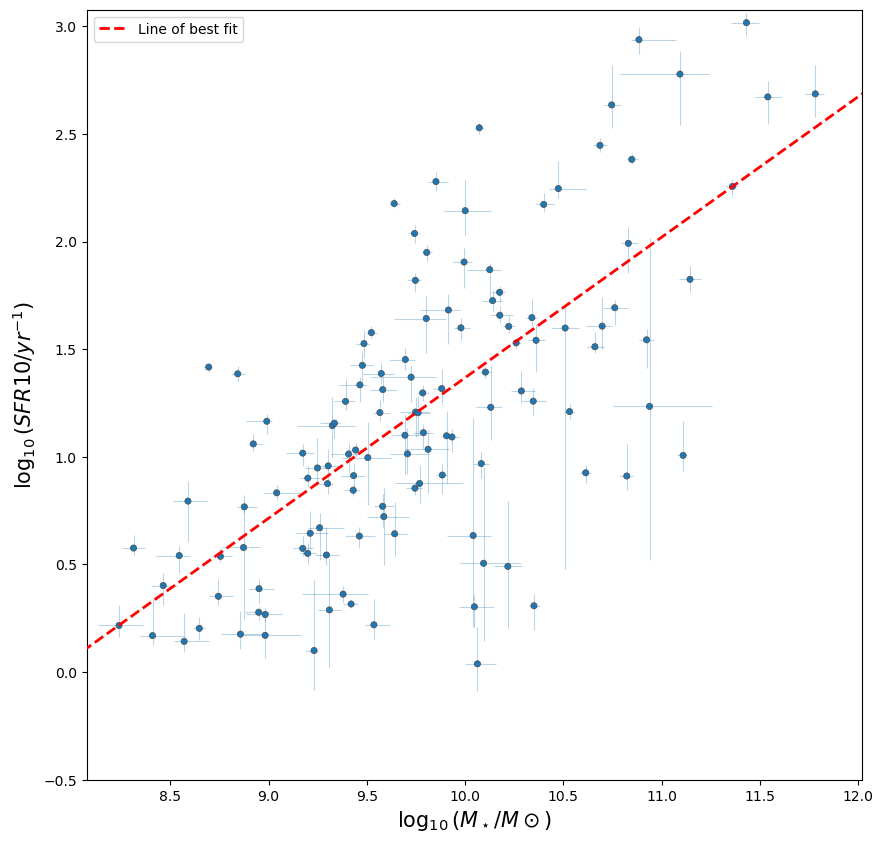

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:05<00:00, 399.72it/s]



For plot below: 
Reduced chi squared = 47
Scatter from fit = 0.406
Scatter (NMAD of normalised residuals) = 5.795


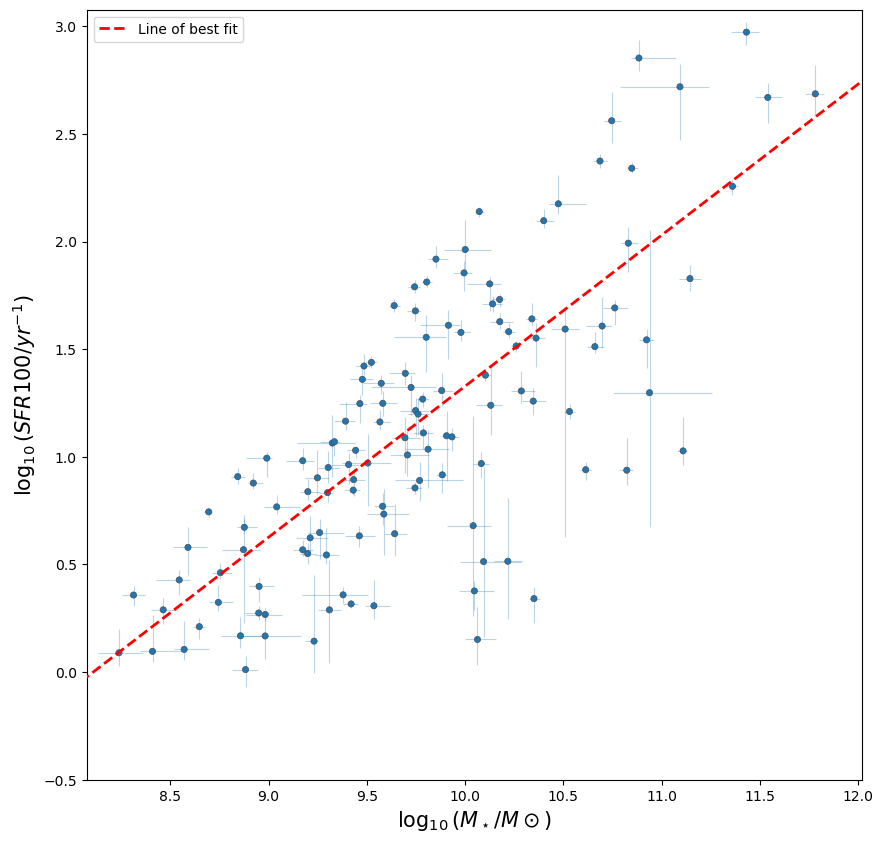

Line of best fit equation: 


<IPython.core.display.Math object>

/tmp/ipykernel_1350991/1494997328.py:38: RuntimeWarning: divide by zero encountered in log10
  log_sSFR10_lower_err = log_sSFR10 - np.log10(sSFR10 - sSFR10_lower_err)
100%|██████████| 2000/2000 [00:04<00:00, 426.71it/s]



For plot below: 
Reduced chi squared = 90.5
Scatter from fit = 0.568
Scatter (NMAD of normalised residuals) = 5.505


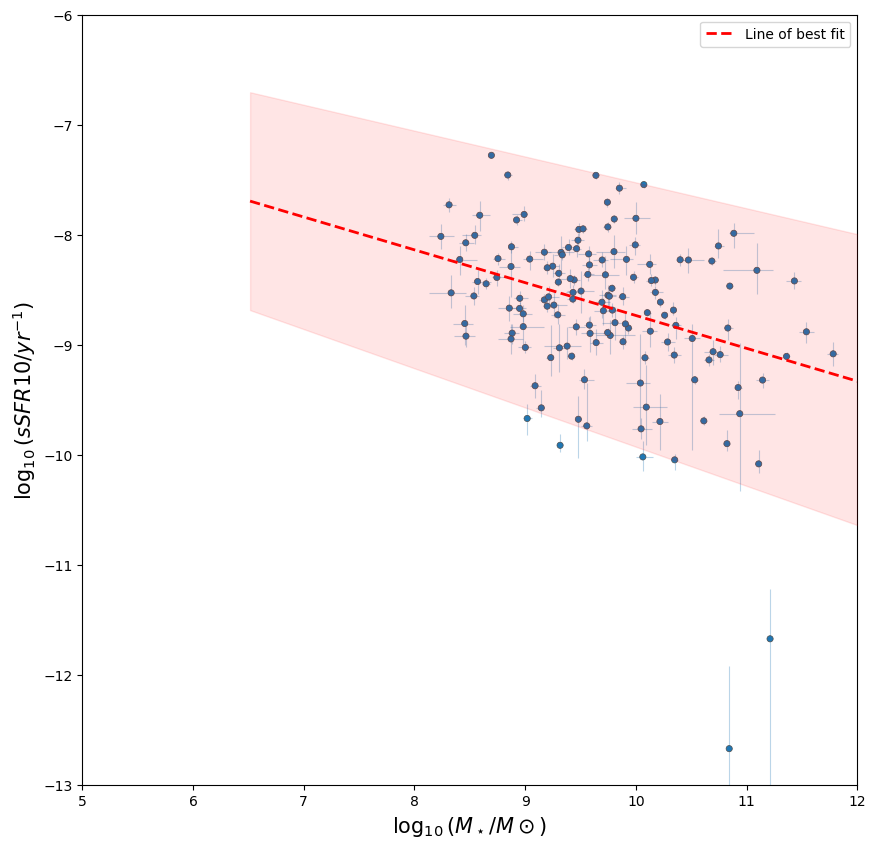

Line of best fit equation: 


<IPython.core.display.Math object>

/tmp/ipykernel_1350991/1494997328.py:90: RuntimeWarning: divide by zero encountered in log10
  log_sSFR100_lower_err = log_sSFR100 - np.log10(sSFR100 - sSFR100_lower_err)
100%|██████████| 2000/2000 [00:05<00:00, 371.08it/s]



For plot below: 
Reduced chi squared = 57.7
Scatter from fit = 0.483
Scatter (NMAD of normalised residuals) = 5.093


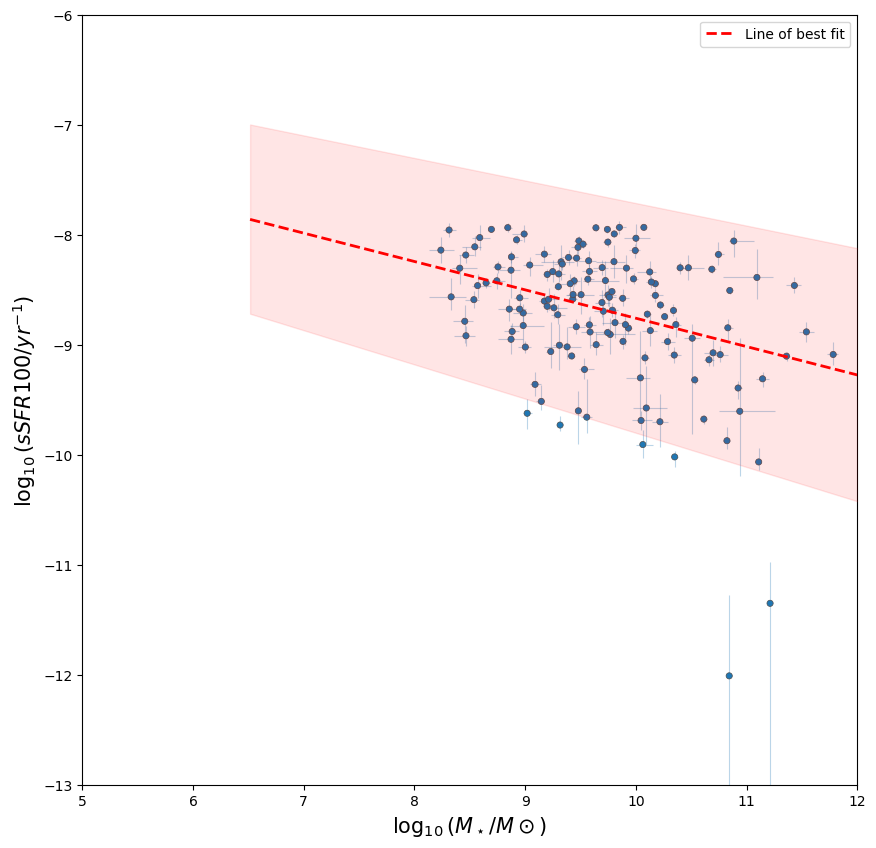

Line of best fit equation: 


<IPython.core.display.Math object>

/tmp/ipykernel_1350991/1959957913.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


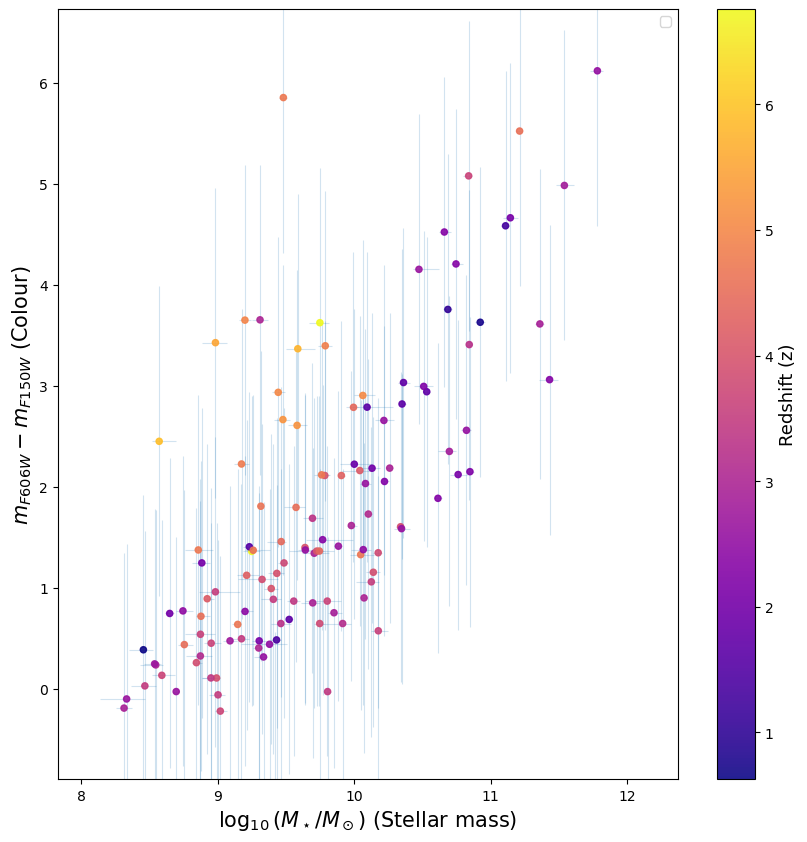


Plot of black hole mass against stellar mass from SED fit of stellar and AGN component


100%|██████████| 2000/2000 [00:04<00:00, 413.12it/s]



For plot below: 
Reduced chi squared = 648
Scatter from fit = 0.822
Scatter (NMAD of normalised residuals) = 8.897


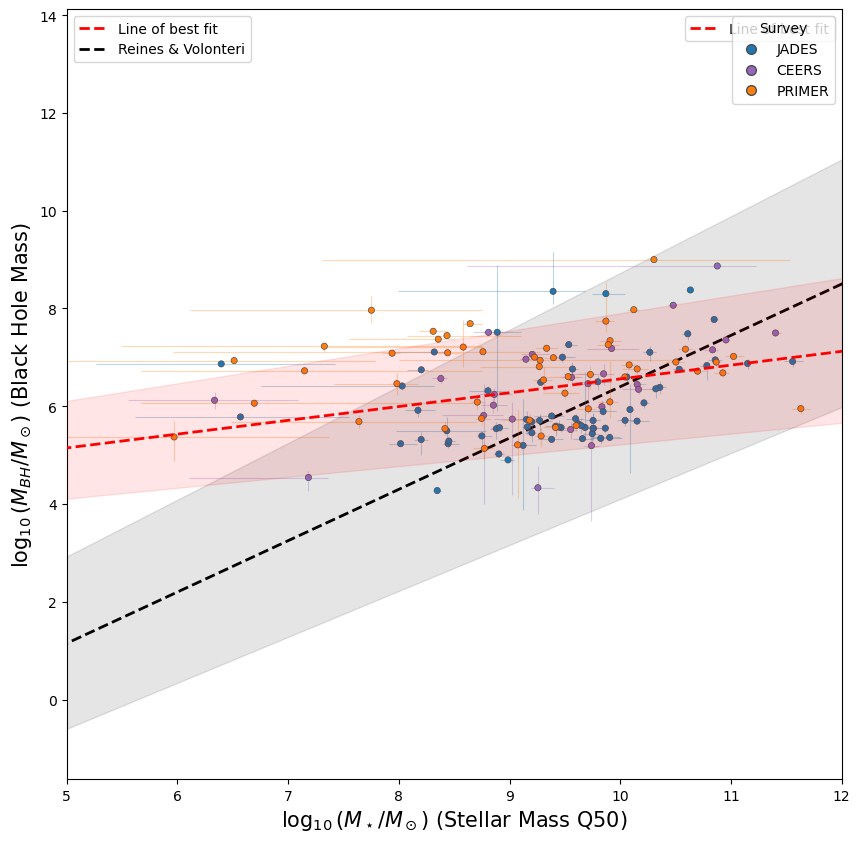

Line of best fit equation: 


<IPython.core.display.Math object>


Reines & Volonteri equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 453.50it/s]



For plot below: 
Reduced chi squared = 65.4
Scatter from fit = 0.772
Scatter (NMAD of normalised residuals) = 5.929


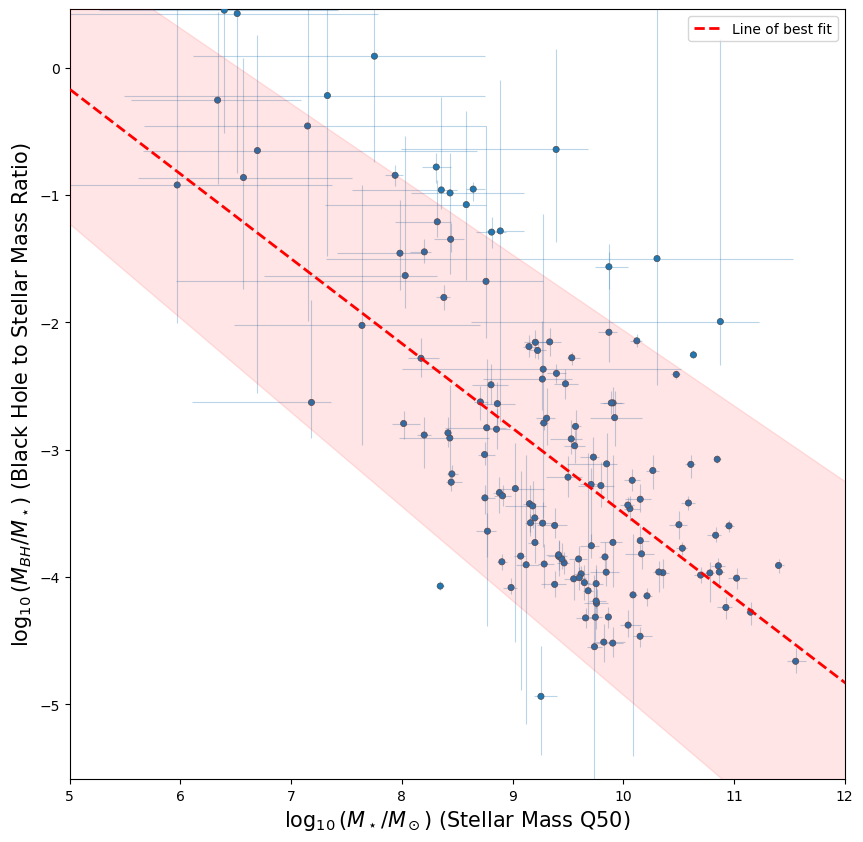

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:05<00:00, 366.58it/s]



For plot below: 
Reduced chi squared = 52.3
Scatter from fit = 0.791
Scatter (NMAD of normalised residuals) = 5.206


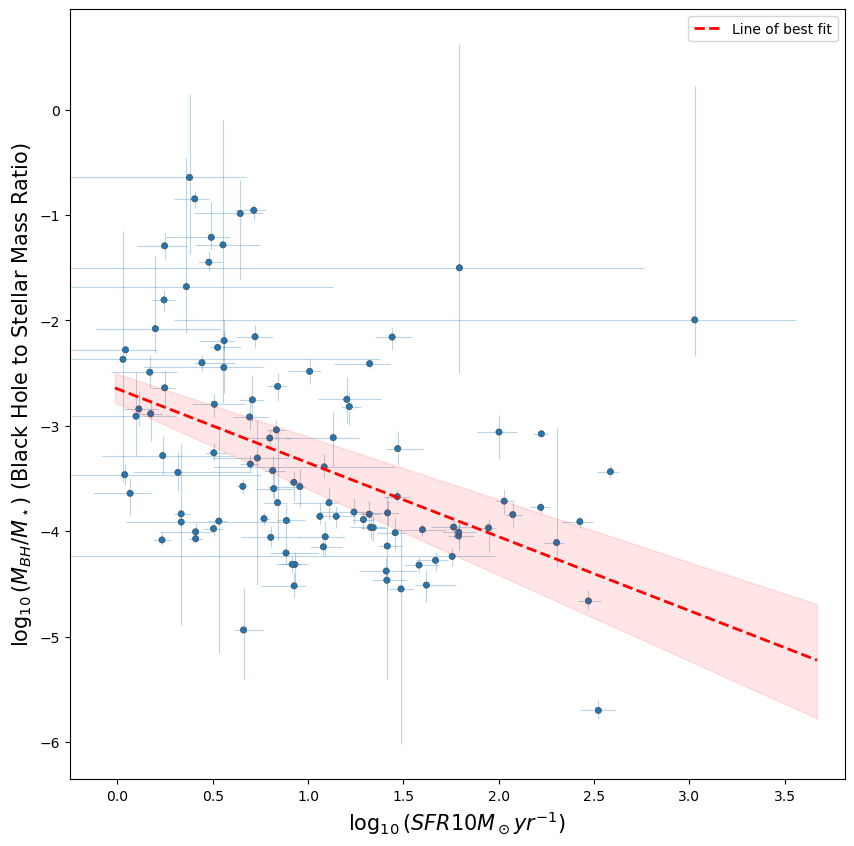

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:05<00:00, 363.63it/s]



For plot below: 
Reduced chi squared = 51.8
Scatter from fit = 0.761
Scatter (NMAD of normalised residuals) = 5.118


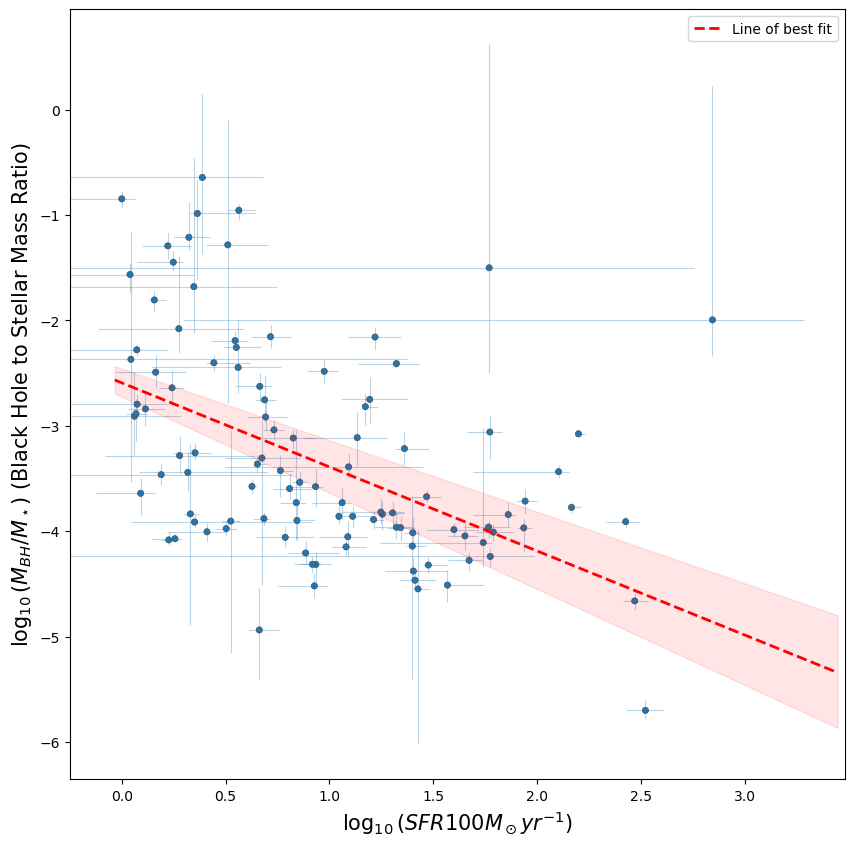

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:05<00:00, 367.16it/s]



For plot below: 
Reduced chi squared = 30
Scatter from fit = 0.417
Scatter (NMAD of normalised residuals) = 4.220


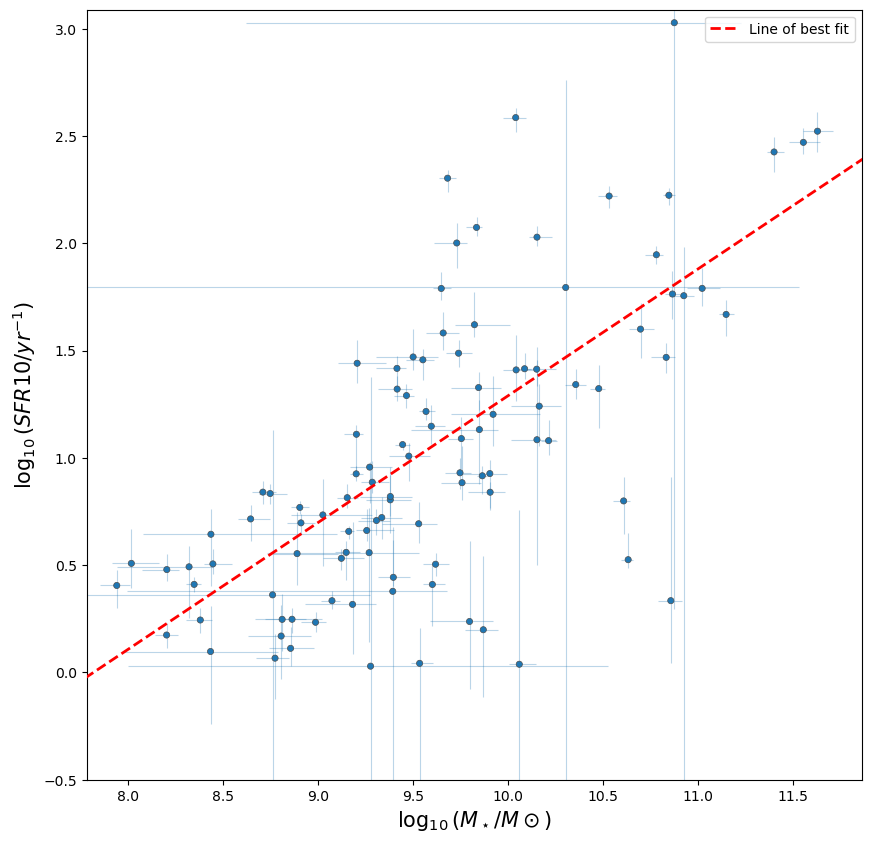

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 441.26it/s]



For plot below: 
Reduced chi squared = 19.2
Scatter from fit = 0.350
Scatter (NMAD of normalised residuals) = 3.360


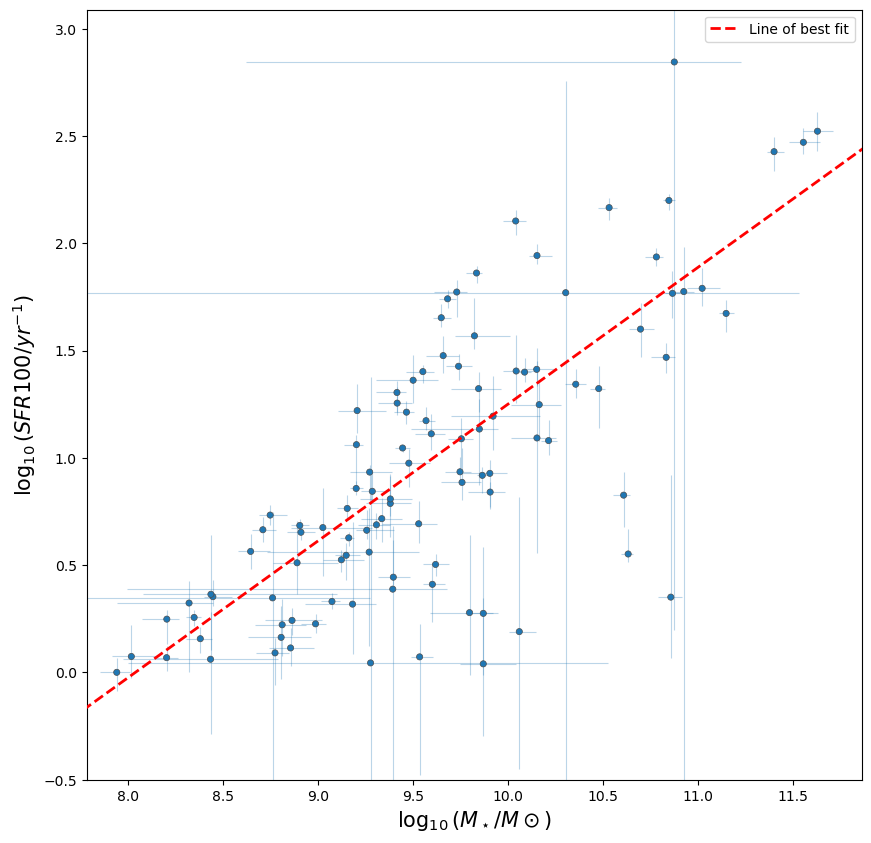

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 402.31it/s]



For plot below: 
Reduced chi squared = 26.6
Scatter from fit = 0.491
Scatter (NMAD of normalised residuals) = 3.273


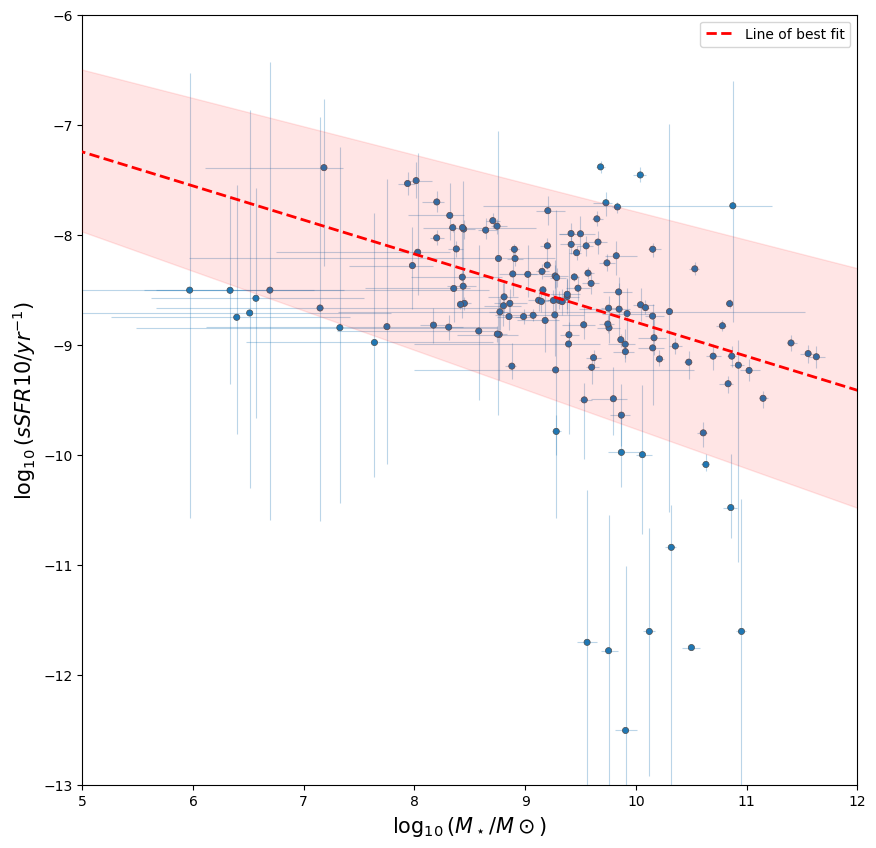

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:05<00:00, 386.58it/s]



For plot below: 
Reduced chi squared = 19.8
Scatter from fit = 0.407
Scatter (NMAD of normalised residuals) = 3.045


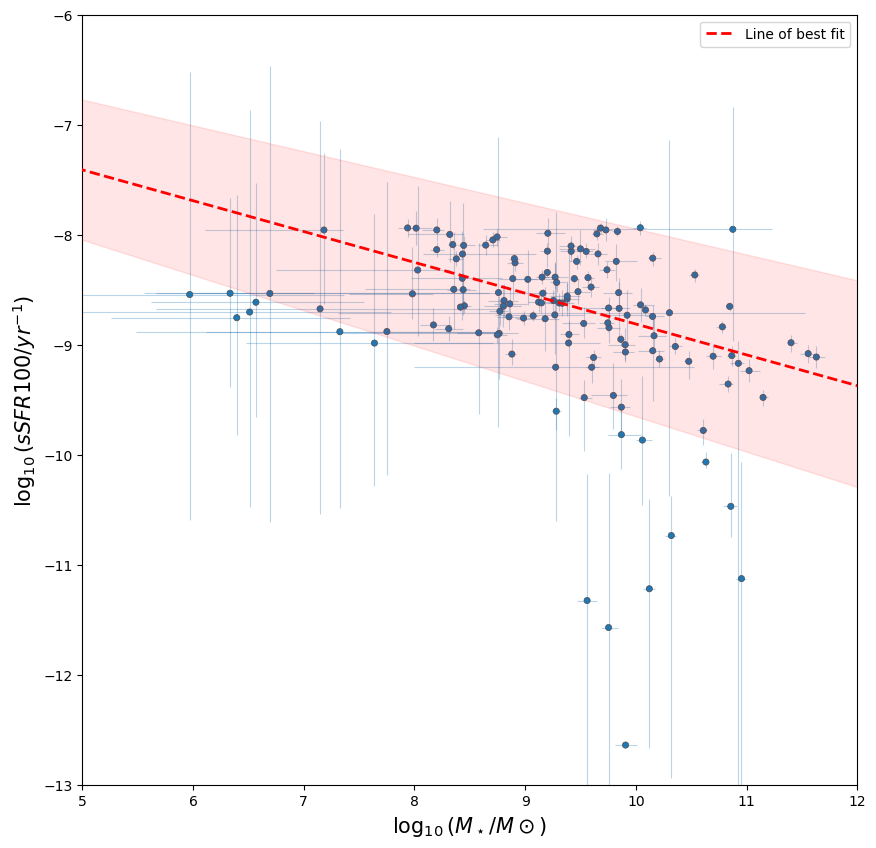

Line of best fit equation: 


<IPython.core.display.Math object>

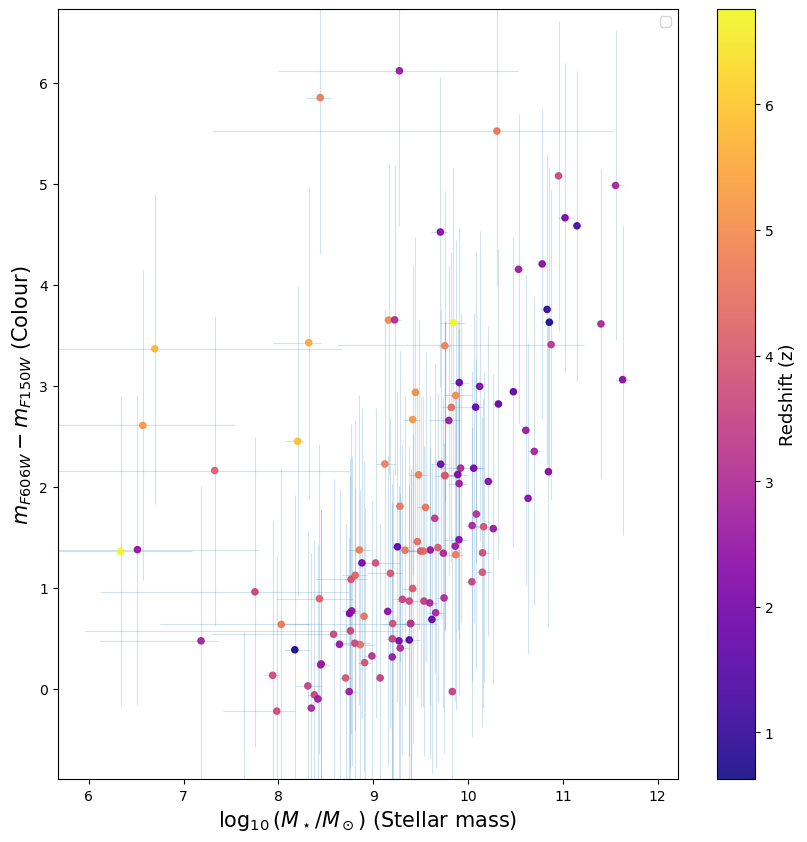

100%|██████████| 2000/2000 [00:04<00:00, 477.03it/s]



For plot below: 
Reduced chi squared = 62.6
Scatter from fit = 0.239
Scatter (NMAD of normalised residuals) = 3.992


/tmp/ipykernel_1350991/246653900.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


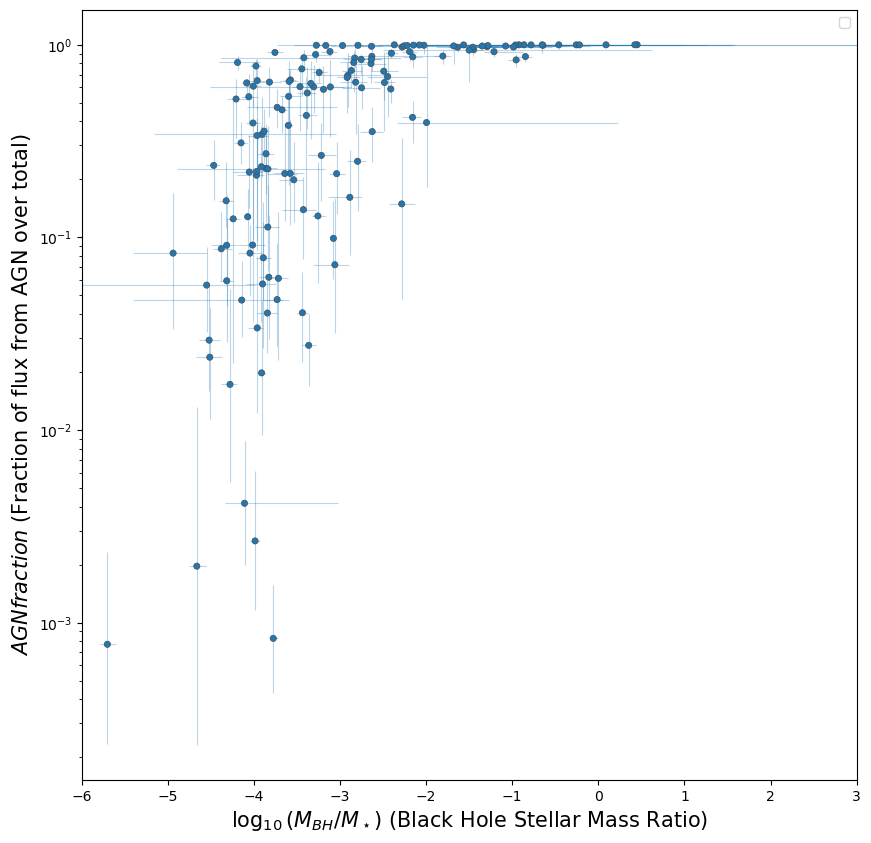

Line of best fit equation: 


<IPython.core.display.Math object>

/tmp/ipykernel_1350991/3333966873.py:15: RuntimeWarning: invalid value encountered in log10
  log_bh_mass_lower_err = log_bh_mass - np.log10(bh_mass - bh_mass_lower_err)
100%|██████████| 2000/2000 [00:04<00:00, 430.40it/s]



For plot below: 
Reduced chi squared = 1.17e+03
Scatter from fit = 1.533
Scatter (NMAD of normalised residuals) = 2.104


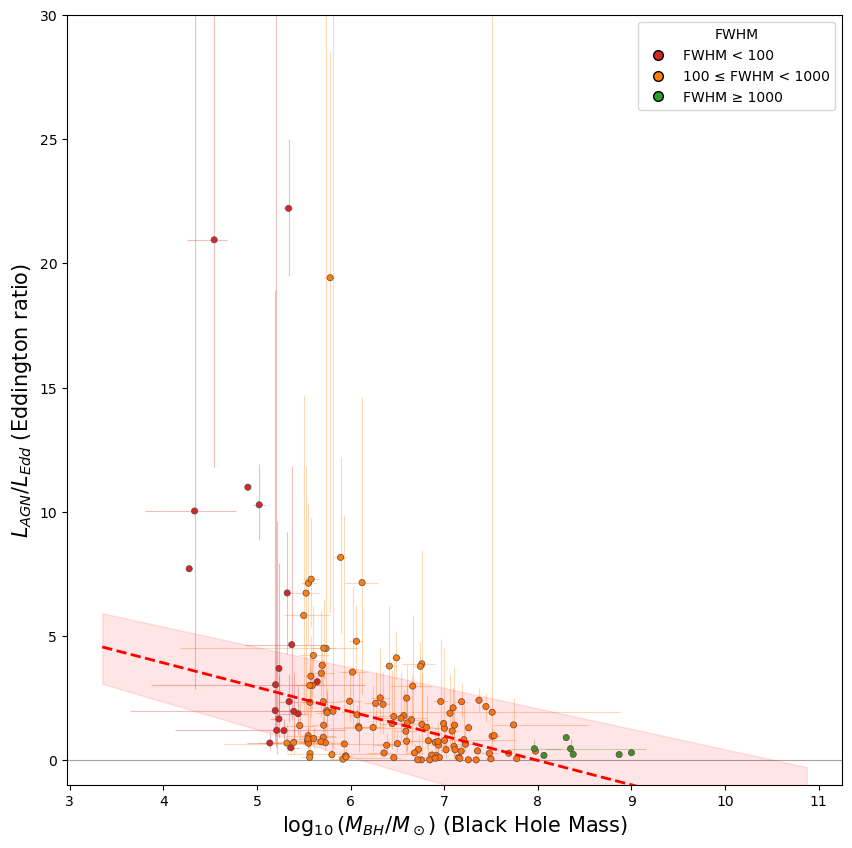

Line of best fit equation: 


<IPython.core.display.Math object>

In [120]:
if __name__ == "__main__":
    #-----------------------------------------------------------------------------------------------------------------------
    stellar_only_and_galaxy_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits")
    
    stellar_AGN_and_galaxy_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_AGN_galaxy_table.fits")

    combined_SED_tables = join(
        stellar_only_and_galaxy_table,
        stellar_AGN_and_galaxy_table,
        keys="SURVEY_ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )

    plot_stellar_masses(combined_SED_tables)

    filtered_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits")
    
    bhm_vs_sm_plot_same_axis(stellar_only_and_galaxy_table, stellar_AGN_and_galaxy_table, filtered_table)
    
    #-----------------------------------------------------------------------------------------------------------------------
    print("")
    print("Plot of black hole mass against stellar mass from SED fit of stellar light only")
    
    bhm_vs_sm_plot(stellar_only_and_galaxy_table)
    
    stellar_only_and_galaxy_table = bhsmr_plots(stellar_only_and_galaxy_table)
    # Table now has columns for bhsmr and its errors
    
    SFR_vs_M(stellar_only_and_galaxy_table)
    
    stellar_only_and_galaxy_table = sSFR_vs_M(stellar_only_and_galaxy_table)
    # Now has sSFR data
    stellar_only_and_galaxy_table = plot_galaxy_colours(stellar_only_and_galaxy_table)

    stellar_only_and_galaxy_table.write("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits", format="fits", overwrite=True)

    #-----------------------------------------------------------------------------------------------------------------------
    print("")
    print("Plot of black hole mass against stellar mass from SED fit of stellar and AGN component")
    bhm_vs_sm_plot(stellar_AGN_and_galaxy_table)
    
    stellar_AGN_and_galaxy_table = bhsmr_plots(stellar_AGN_and_galaxy_table)
    # Table now has columns for bhsmr and its errors
    
    SFR_vs_M(stellar_AGN_and_galaxy_table)

    stellar_AGN_and_galaxy_table = sSFR_vs_M(stellar_AGN_and_galaxy_table)
    # Now has sSFR data
    stellar_AGN_and_galaxy_table = plot_galaxy_colours(stellar_AGN_and_galaxy_table)

    AGNfrac_vs_bhsmr(stellar_AGN_and_galaxy_table)

    edd_ratio_vs_bh_m(stellar_AGN_and_galaxy_table)

    stellar_AGN_and_galaxy_table.write("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_AGN_galaxy_table.fits", format="fits", overwrite=True)

    #-----------------------------------------------------------------------------------------------------------------------
   
    